# Import 

In [29]:
import h5py
from seisbench.models import CRED,EQTransformer,PhaseNet,GPD,OBSTransformer
import numpy as np
from seisbench.data import WaveformDataset
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
from obspy import Stream, Trace
from tqdm import  tqdm 
import matplotlib.transforms as mtransforms
import nest_asyncio
nest_asyncio.apply()
import datetime

from sklearn.metrics import recall_score, balanced_accuracy_score

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


global clockt1

def tic():
    global clockt0
    clockt0 = datetime.datetime.now()

def toc():
    global clockt1
    clockt1 = datetime.datetime.now()

def tac():
    global clockt1
    global clockt0
    d = clockt1 - clockt0
    return d.total_seconds()
    
def try_treshold(prob,labels):
    VecR = []
    VecA = []
    px= np.arange(0,1,0.01)
    for p in  px : 
        #Score = np.sum([ip>p for ip in prob])/len(prob)*100
        VecR.append(recall_score(labels,[ip>p for ip in prob]))
        VecA.append(balanced_accuracy_score(labels,[ip>p for ip in prob]))
    return np.array(VecR),px,np.array(VecA)

def try_SNR(prob,SNR,labels):
    VecR = []
    VecA = []
    Nv= []
    px= list(np.arange(0,8,1))
    SNR = np.array(SNR)
    SNR[SNR>px[-1]] = px[-2]
    classe = np.array([ip>0.50 for ip in prob])
    for k in range(len(px)-1) : 
        iisnr=np.where( (SNR>=px[k]) & (SNR<px[k+1]))
        #Score = np.sum( [ip>0.50 for ip in prob[iisnr]] )/(len(prob[iisnr]) + 1e-11)*100 *(np.nan,1)[len(prob[ii])>0]
        Nv  = Nv+[len(iisnr[0])]
        if Nv[-1]>0:
            VecR.append(recall_score(labels[iisnr],classe[iisnr]))
            VecA.append(balanced_accuracy_score(labels[iisnr],classe[iisnr]))
        else:
            VecR.append(0)
            VecA.append(0)
    return np.array(VecR),np.array(px), Nv,np.array(VecA)

def try_HZ(prob,HZ,labels):
    VecR = []
    VecA = []
    Nv= []
    px= list(np.arange(300,1500,100))
    HZ = np.array(HZ)
    HZ[HZ>px[-1]] = px[-2]
    classe = np.array([ip>0.50 for ip in prob])
    for k in range(len(px)-1) : 
        iisnr=np.where( (HZ>=px[k]) & (HZ<px[k+1]))
        #Score = np.sum( [ip>0.50 for ip in prob[iisnr]] )/(len(prob[iisnr]) + 1e-11)*100 *(np.nan,1)[len(prob[ii])>0]
        Nv  = Nv+[len(iisnr[0])]
        if Nv[-1]>0:
            VecR.append(recall_score(labels[iisnr],classe[iisnr]))
            VecA.append(balanced_accuracy_score(labels[iisnr],classe[iisnr]))
        else:
            VecR.append(0)
            VecA.append(0)
    return np.array(VecR),np.array(px), Nv,np.array(VecA)


plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'figure.titlesize': 26  # Taille du titre de la figure
})

"""
axes.titlesize : 24
axes.labelsize : 20
lines.linewidth : 3
lines.markersize : 10
xtick.labelsize : 16
ytick.labelsize : 16
"""
def plotprobs(prob,labels):
    bins=np.arange(0,1.1,0.1)
    selection = np.where(labels==0)
    recp , px , accp = try_treshold(1-prob[selection],[1]*len(selection[0]))
    figdist = plt.figure(figsize=(25,6))
    plt.subplot(1,3,1)
    plt.hist(1-prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Noise Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Noise class Probablity')
    plt.subplot(1,3,2)
    selection = np.where(labels==1)
    recp , px , accp = try_treshold(prob[selection],[1]*len(selection[0]))
    plt.hist(prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Signal Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Signal class Probablity')

    plt.subplot(1,3,3)
    recp , px , accp = try_treshold(prob,labels)
    plt.hist([prob[i] if labels[i]==1 else 1-prob[i] for i in range(len(prob))],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Class Probability')
    ax =plt.twinx()
    plt.plot(px,accp,color='#712F79',ls='-',label='Accuracy',lw=4)
    plt.plot(px,recp,color='#48639C',ls='-',label='Recall',lw=4)
    f1sc=2*accp*recp/(recp+accp+1e-11)
    plt.plot(px, f1sc, color='#F7999E',ls='-',label='F1-scor',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.legend(loc='lower right')
    plt.title('Combined class Probablity')
    ima = np.argmax(f1sc)
    plt.axvline(x=px[ima],ls=':',color='red')
    trans_offset = mtransforms.offset_copy(ax.transData, fig=figdist,
                                       x=0.05, y=0.10, units='inches')
    plt.text(px[ima], (np.nanmax(f1sc)+np.nanmin(f1sc))/2, f' {f1sc[ima]:.2f} at {px[ima]:.2f} ', dict(size=18),
             transform=trans_offset,
             horizontalalignment='center',
             verticalalignment='bottom',
             color ='red')
    plt.tight_layout()
    plt.show()

    snrrec, snrx , Nv,snracc = try_SNR(prob,np.array(SNR),labels)
    figsnr=plt.figure(figsize=(9,5))
    n=1*3
    offset=(1/n)
    plt.bar(snrx[:-1]/2+snrx[1:]/2 - 2/3 * offset,snrrec,width=1/(2*n),label='Recall',color='#48639C')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 ,snracc,width=1/(2*n),label='Accuracy',color='#712F79')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 + 2/3* offset,2*snracc*snrrec/(snrrec+snracc+1e-11),width=1/(2*n),label='F1-score',color='#F7999E')
    plt.xlabel('SNR')
    plt.ylabel('Score')
    plt.legend(loc='lower right')
    plt.twinx()
    plt.plot(snrx[:-1]/2+snrx[1:]/2,Nv,color='k',ls = ':',lw=4)
    plt.ylabel('Number')
    plt.title('Score at 50% treshold against SNR ')
    plt.show()

    return figdist,figsnr, [f1sc[ima],px[ima],recp[ima],accp[ima]]
    
def convert_1d_to_3d(waveform_1d):
    # Repeat the 1D waveform for all 3 components
    return torch.stack([waveform_1d, waveform_1d, waveform_1d], dim=0)

def pad_to_multiple(x, multiple=256):
    length = x.shape[-1]
    pad_len = (multiple - length % multiple) % multiple
    if pad_len > 0:
        x = F.pad(x, (0, pad_len))
    return x
    
sampling_rate = 100#10e6
class CustomWaveformDataset_Seisbench(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveforms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        waveform_stacked = self.waveforms[idx]
        waveforms_np = pad_to_multiple(torch.tensor(waveform_stacked), multiple=256).numpy()
        st = Stream()

        # Create a Trace for each component
        for i, component in enumerate(waveforms_np):
            trace = Trace(data=component)
            trace.stats.channel = f"Component_{i+1}"  # Name the channels
            trace.stats.sampling_rate = sampling_rate
    
            st.append(trace)
        
        waveform_3d = st
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return waveform_3d, label

class CustomWaveformDataset_IsAE(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveform,Spectrograms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        self.Spectrograms =  Spectrograms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        
        return  torch.tensor(self.Spectrograms[idx]), _

def  MakeSNR(waveforms):
    #SNR = [np.nanmax(np.abs(waveform[1]))/(np.max(np.abs(waveform[1][:len(waveform[1])//6]))+1e-11) for waveform in waveforms ]
    rms = lambda y : np.sqrt(np.mean(y**2))
    SNR = [rms(waveform[0])/(rms(waveform[1][:len(waveform[0])//6])+1e-11) for waveform in waveforms ]
   
    #SNR = [ signaltonoise(waveform[0]) for waveform in waveforms ]
    return SNR


Task was destroyed but it is pending!
task: <Task pending name='Task-95342' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-95343' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-95343' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>


In [30]:


def max_frequency(waveform, sample_rate):
    """
    Calculate the maximum frequency in a waveform after de-trending.

    Parameters:
    - waveform: 1D array of the time-domain signal.
    - sample_rate: Sampling rate of the waveform in Hz.

    Returns:
    - Maximum frequency in kHz.
    """
    # De-trend the waveform (remove linear trend)
    x = np.arange(len(waveform))
    coeffs = np.polyfit(x, waveform, 1)
    trend = np.polyval(coeffs, x)
    detrended_waveform = waveform - trend

    # Compute FFT
    n = len(detrended_waveform)
    fft_result = np.abs(np.fft.fft(detrended_waveform))
    freqs = np.fft.fftfreq(n, d=1/sample_rate)

    # Only consider positive frequencies
    positive_freqs = freqs[:n//2]
    positive_magnitudes = fft_result[:n//2]

    max_freq_idx = np.argmax(positive_magnitudes)
    max_freq = positive_freqs[max_freq_idx]

    return max_freq / 1000  # Convert to kHz


# Testing on SeisBench Available Models and IsAE on Our Dataset

In [54]:
## Iniatialize Best rate dic
BestP1 = {}
BestT1 = {}
BestR1 = {}
BestA1 = {}

## load data

In [78]:
file = 'dataset_all'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    paths = f.attrs['paths']
    times = f.attrs['times']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

MaxFrqsOD = np.array([max_frequency(w[0],10*1e6) for w in waveforms])
LabelOD = labels

print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(paths))

# Initialize the dataset For Natural Trained Earthquakes
datasetOD = CustomWaveformDataset_Seisbench(paths, labels, times, waveforms)
dataset_IsAEOD = CustomWaveformDataset_IsAE(paths, labels, times, waveforms,Spectrogram)

Dataset loaded from 'dataset_all.h5'.
Number of elements :  2193


In [79]:
print(datasetOD[0][0])  # Should be (3, num_samples) for 3-component data
print(datasetOD[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7f984e5a4500>, tensor(1))


## Cred

In [80]:
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [81]:

pred_list = []
for i in tqdm(range(len(datasetOD))):
    preds = model.annotate(datasetOD[i][0])
    pred_list.append(max(preds[0].data) )
    
pred_list_Cred1 = np.array(pred_list)

  0%|          | 0/2193 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
 51%|█████▏    | 1126/2193 [00:44<00:41, 25.74it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-214850' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-214852' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/pytho

In [ ]:
f1,f2, L = plotprobs(pred_list_Cred1,labels)
BestT1['Cred'] = L[1]
BestP1['Cred'] = L[0]
BestA1['Cred'] = L[3]
BestR1['Cred']= L [2]
f1.savefig("Figure/CRED_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/CRED_Snr_OD.png", dpi=100, bbox_inches='tight')

## EQTransformer

In [10]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [11]:
%autoawait off
pred_list = []
for i in tqdm(range(len(datasetOD))):
    preds = model.annotate(datasetOD[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_EQT1 = np.array(pred_list)

  6%|▌         | 135/2193 [00:07<01:58, 17.43it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
 19%|█▉        | 423/2193 [00:23<01:35, 18.44it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
 28%|██▊       | 611/2193 [00:33<01:28, 17.88it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septie

Task was destroyed but it is pending!
task: <Task pending name='Task-22894' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-22895' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-22895' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-22903' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septie

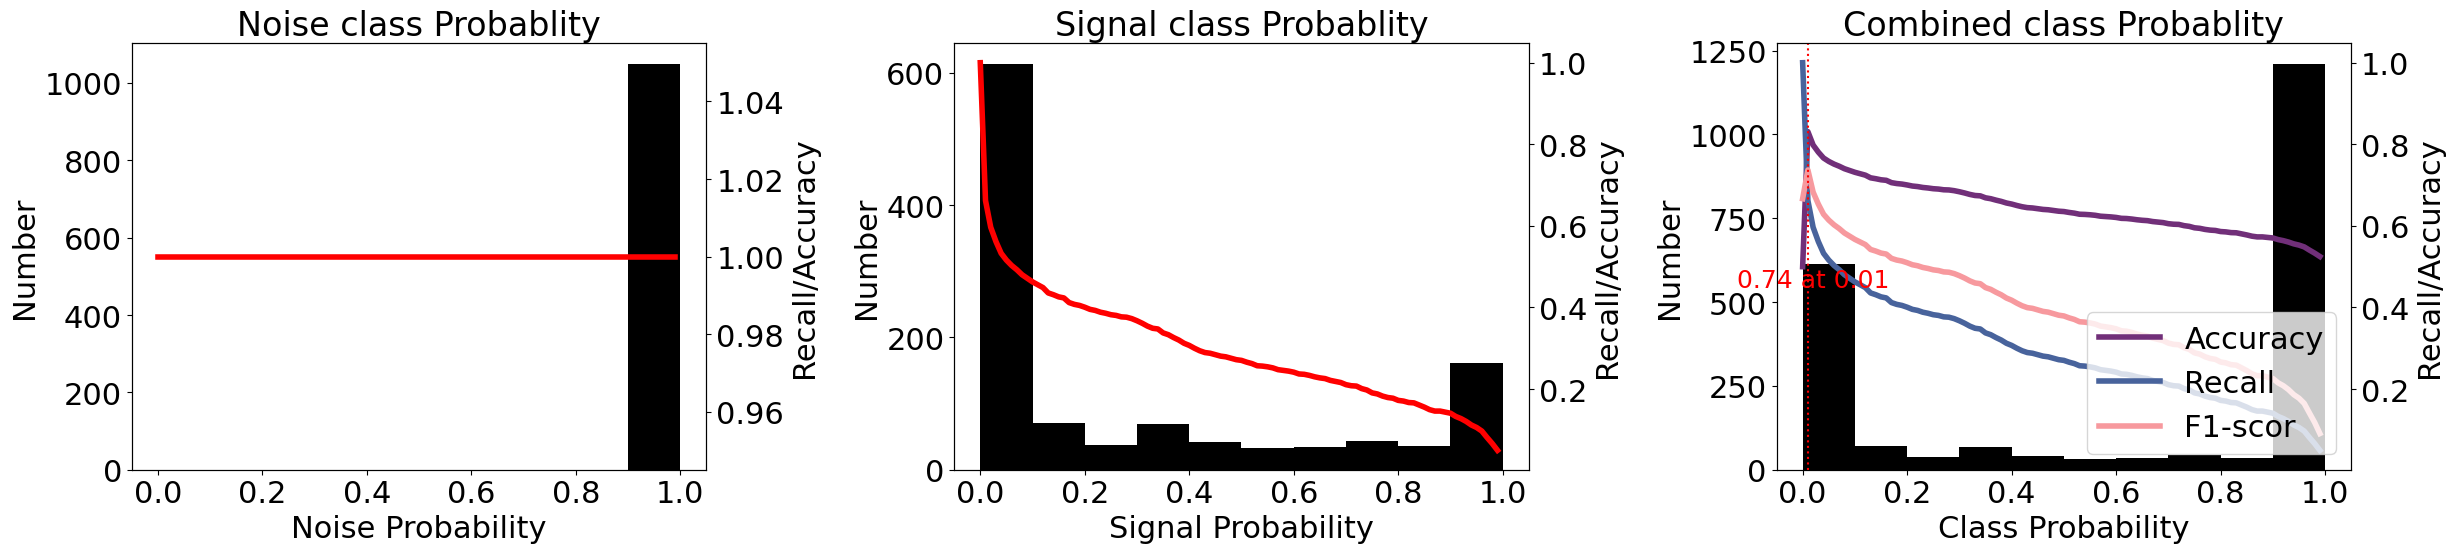

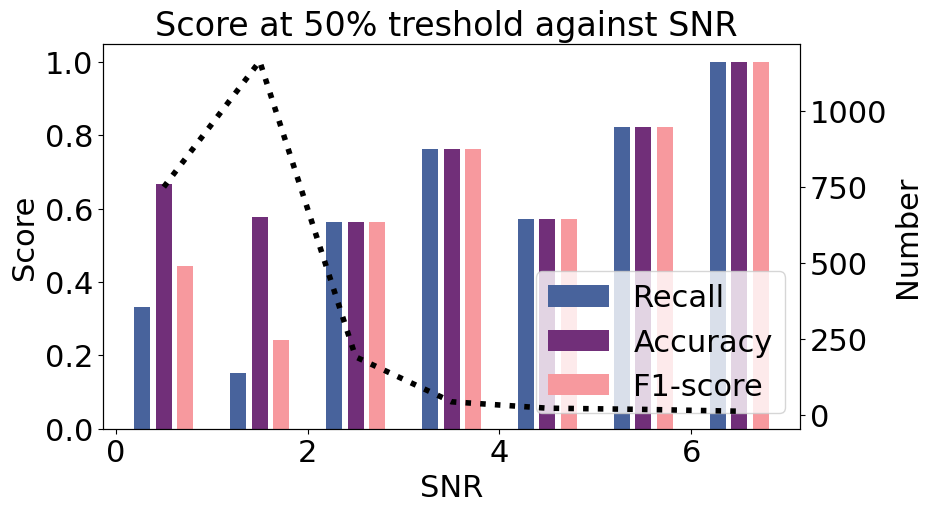

In [12]:
f1,f2, L = plotprobs(pred_list_EQT1,labels)
BestP1['EQT'] = L[0]
BestT1['EQT'] = L[1]
BestA1['EQT'] = L[3]
BestR1['EQT'] = L[2]
f1.savefig("Figure/EQT_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/EQT_Snr_OD.svg", dpi=100, bbox_inches='tight')

## GPD

In [13]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [14]:
%autoawait on

pred_list = []
for i in tqdm(range(len(datasetOD))):
    preds = model.annotate(datasetOD[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_GPD1 = np.array(pred_list)

 14%|█▎        | 298/2193 [00:20<02:12, 14.32it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
 19%|█▉        | 416/2193 [00:28<02:13, 13.33it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
 19%|█▉        | 418/2193 [00:28<02:12, 13.42it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septie

Task was destroyed but it is pending!
task: <Task pending name='Task-29758' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-29759' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-29759' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-29839' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septie

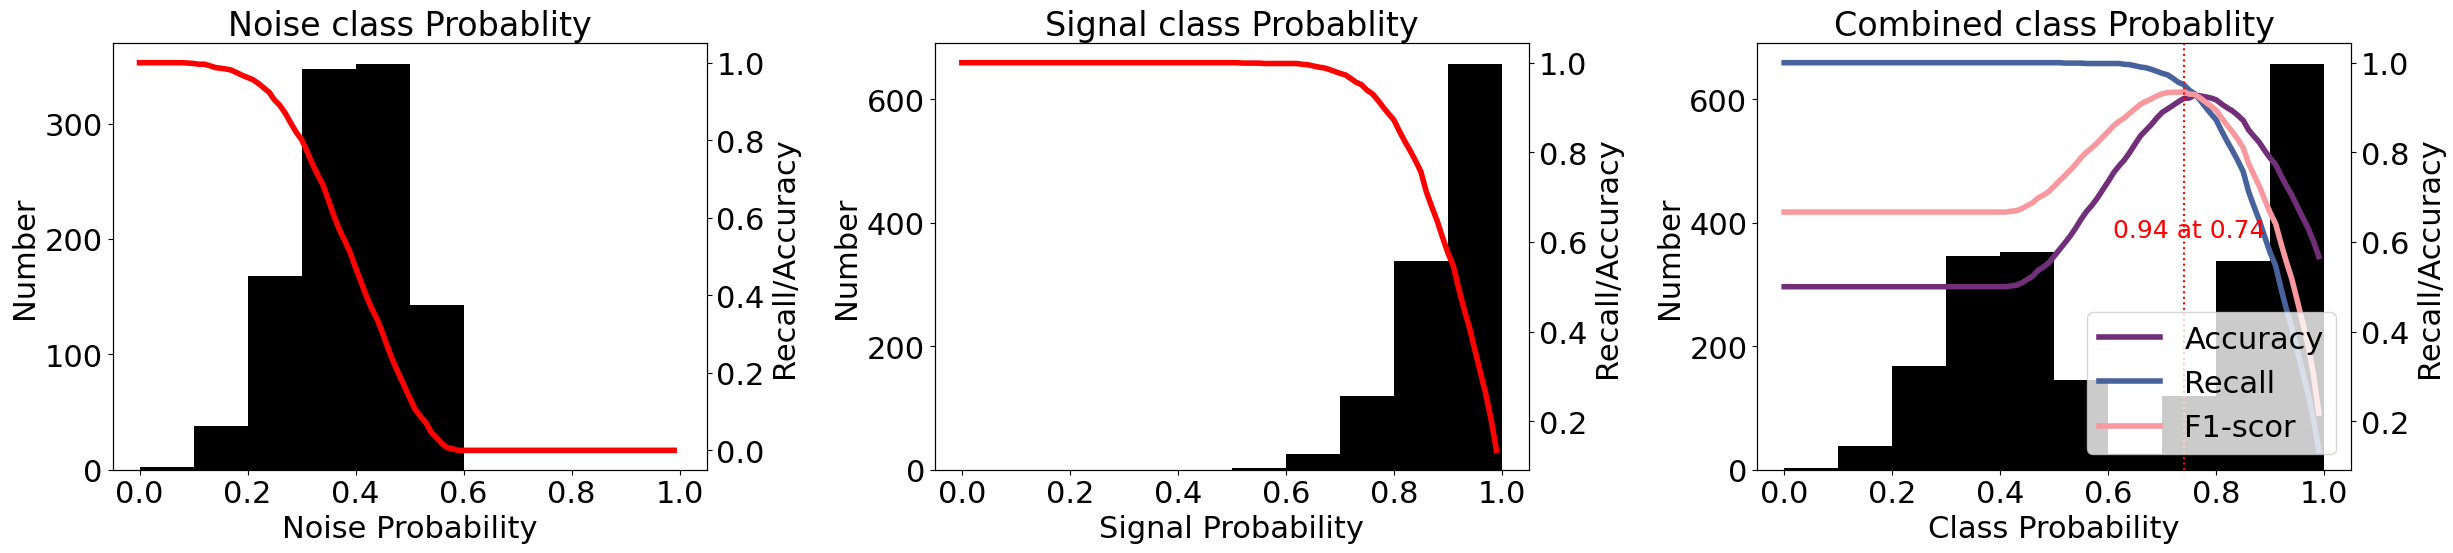

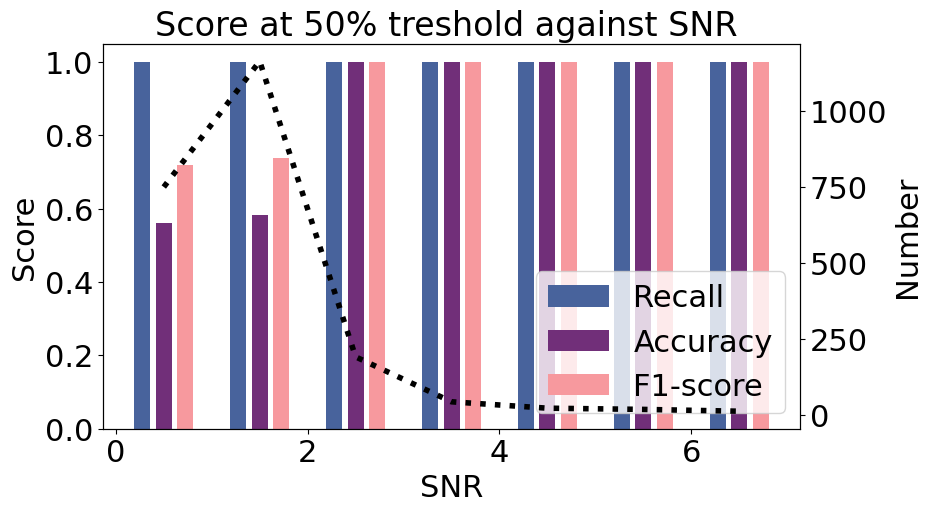

In [15]:
f1,f2, L = plotprobs(pred_list_GPD1,labels)
BestP1['GPD'] = L[0]
BestT1['GPD'] = L[1]
BestA1['GPD'] = L[3]
BestR1['GPD'] = L[2]
f1.savefig("Figure/GPD_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/GPD_Snr_OD.svg", dpi=100, bbox_inches='tight')

## PhaseNet

In [18]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [28]:


pred_list = []
for i in tqdm(range(len(datasetOD))):
    preds = model.annotate(datasetOD[i][0])
    pred_list.append(max(preds[0].data) )

pred_listPhase1 = np.array(pred_list)

 20%|██        | 443/2193 [00:04<00:14, 117.76it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
100%|██████████| 2193/2193 [00:19<00:00, 114.84it/s]


In [ ]:
f1,f2, L = plotprobs(pred_listPhase1,labels)
BestP1['PhaseNet'] = L[0]
BestT1['PhaseNet'] = L[1]
BestA1['PhaseNet'] = L[3]
BestR1['PhaseNet'] = L[2]
f1.savefig("Figure/PhaseNet_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/PhaseNet_Snr_OD.svg", dpi=100, bbox_inches='tight')

## OBSTransformer

In [37]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [38]:
%autoawait on
pred_list = []
for i in tqdm(range(len(datasetOD))):
    preds = model.annotate(datasetOD[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_OBS1 = np.array(pred_list)

  0%|          | 0/2193 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
  0%|          | 2/2193 [00:00<02:02, 17.85it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-106327' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-106329' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.

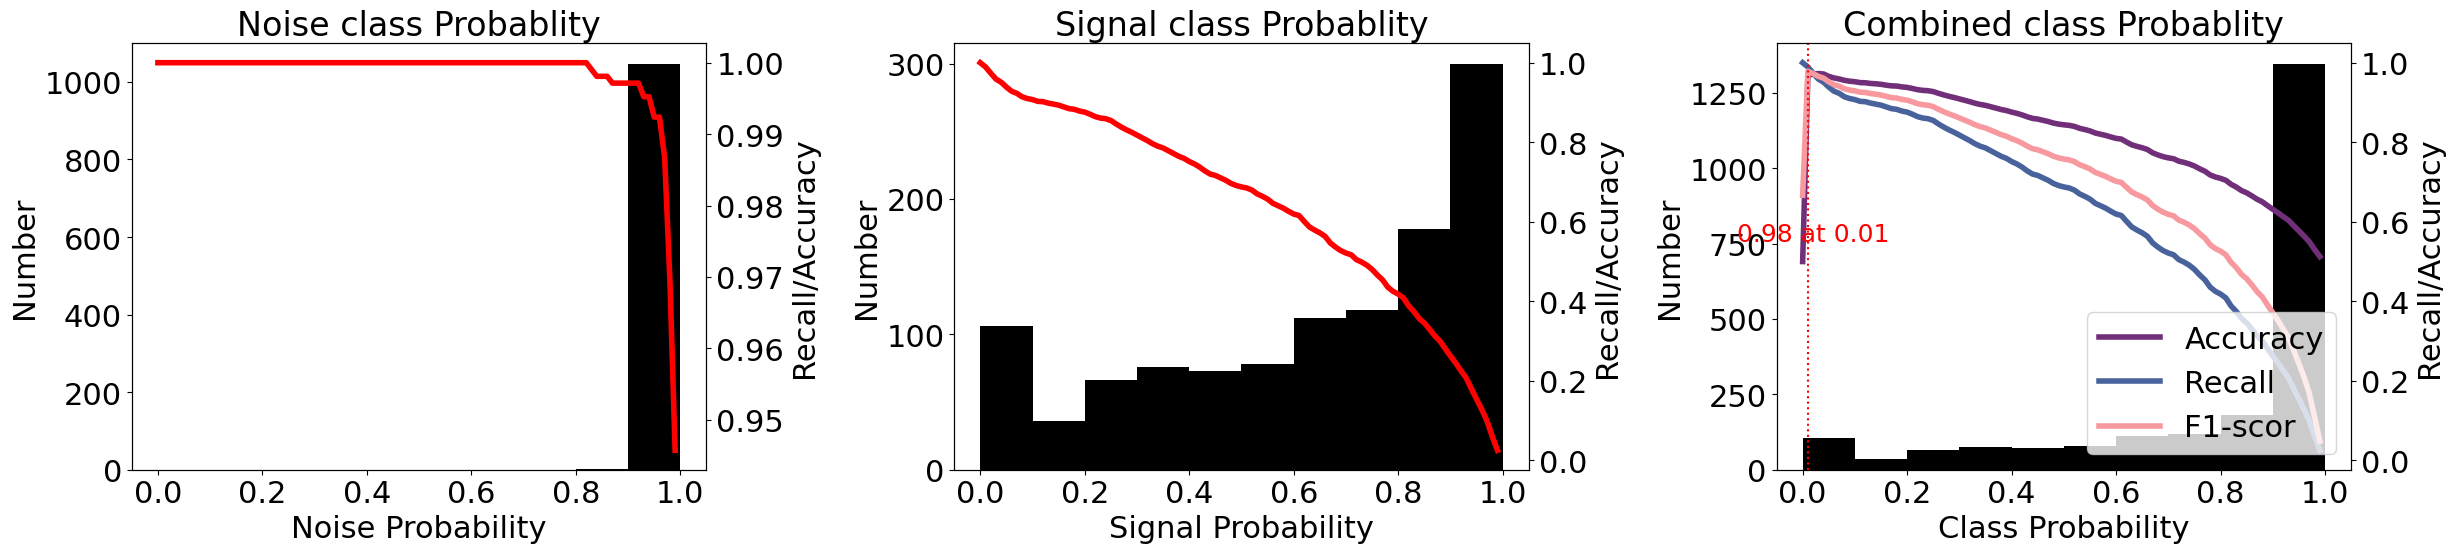

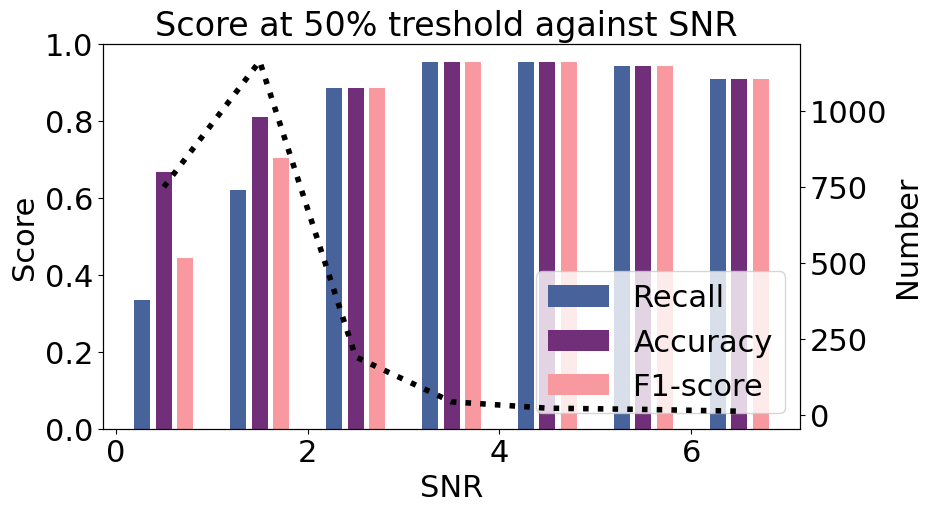

In [58]:
f2,f2, L = plotprobs(pred_list_OBS1,labels)
BestP1['OBS'] = L[0]
BestT1['OBS'] = L[1]
BestA1['OBS'] = L[3]
BestR1['OBS'] = L[2]
f1.savefig("Figure/OBST_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/OBST_Snr_OD.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE NoAE

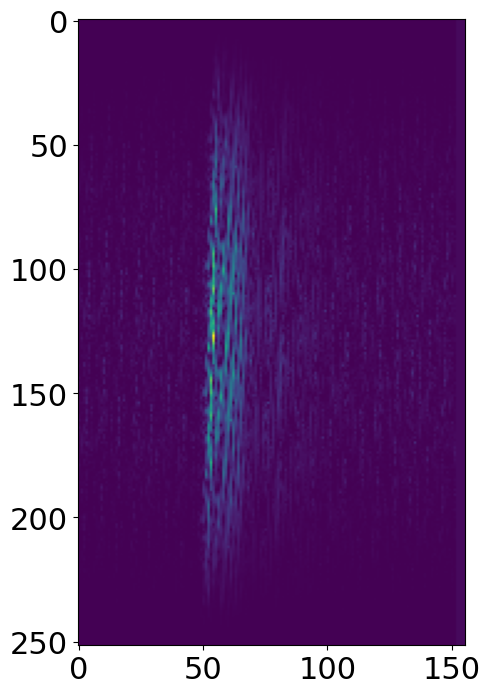

In [33]:
plt.figure(figsize=(5,10))
plt.imshow(Spectrogram[0][0])
plt.show()

In [34]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [35]:
prob = []
for data in tqdm(dataset_IsAEOD):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
pred_list_IsAE1 = np.array(prob)    

100%|██████████| 2193/2193 [00:03<00:00, 581.24it/s]


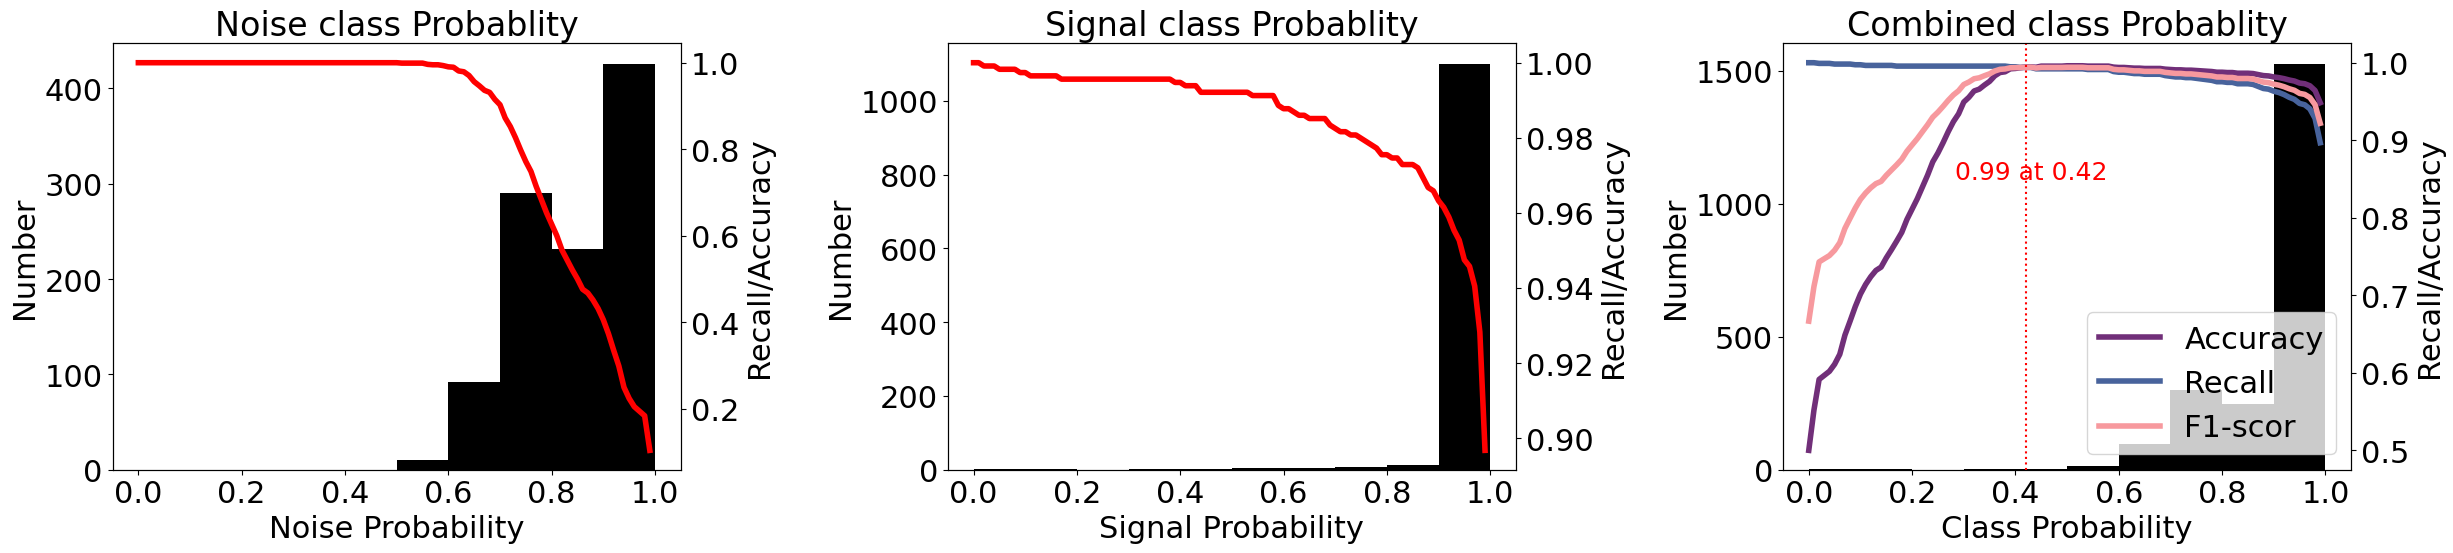

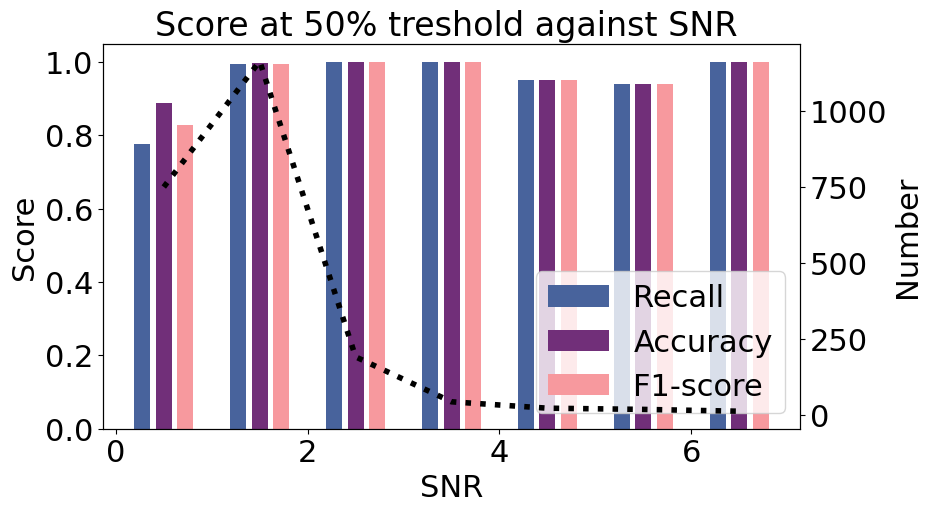

In [36]:
f1,f2, L = plotprobs(pred_list_IsAE1,labels)
BestP1['IsAE'] = L[0]
BestT1['IsAE'] = L[1]
BestA1['IsAE'] = L[3]
BestR1['IsAE'] = L[2]
f1.savefig("Figure/IsAE_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAE_Snr_OD.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE MinUSIL

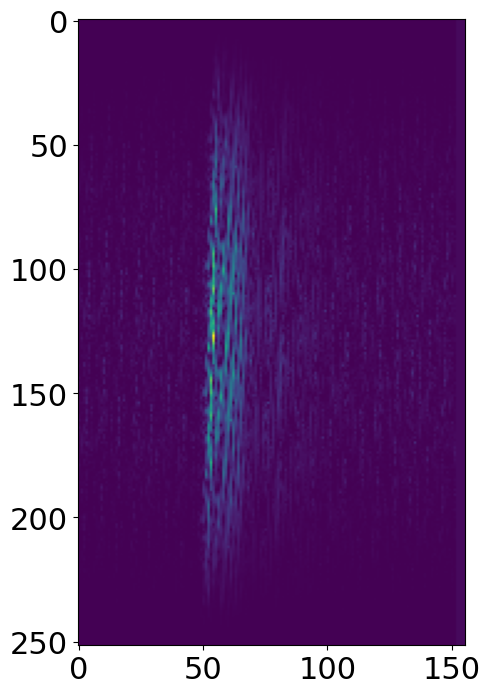

In [438]:
plt.figure(figsize=(5,10))
plt.imshow(Spectrogram[0][0])
plt.show()

In [439]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_MAXPOOL_MINUSIL15.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [440]:
prob = []
for data in tqdm(dataset_IsAEOD):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
pred_list_IsAE1_MIN = np.array(prob)    

100%|██████████| 2193/2193 [00:04<00:00, 518.86it/s]


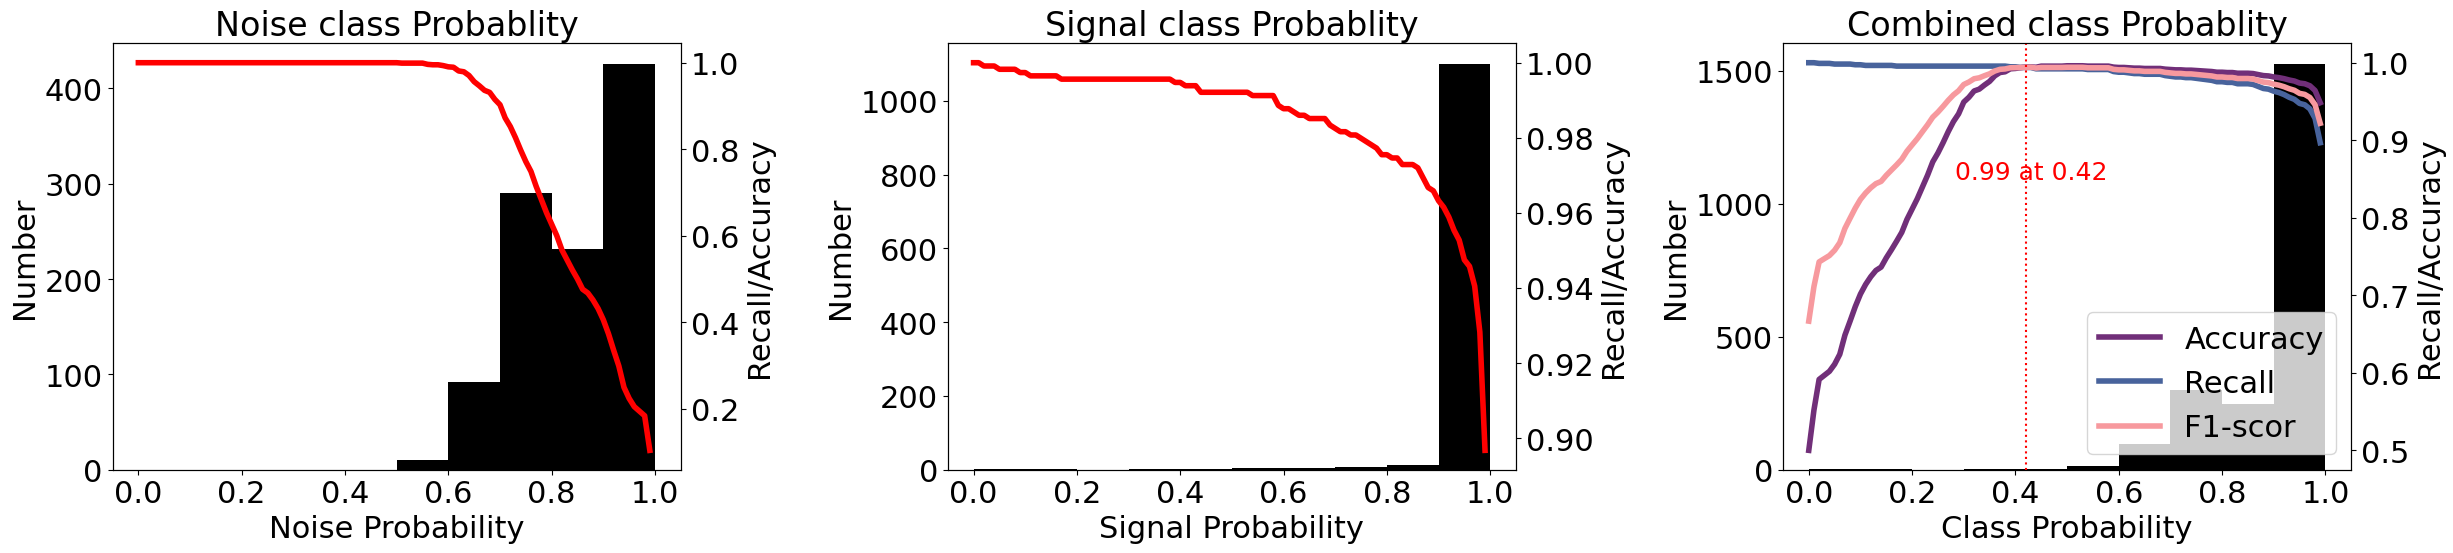

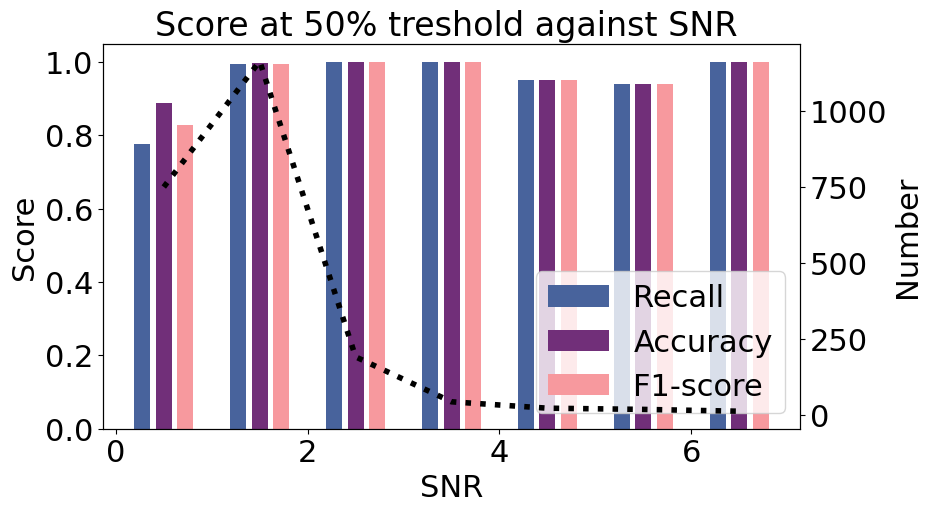

In [441]:
f1,f2, L = plotprobs(pred_list_IsAE1,labels)
BestP1['IsAEMIN'] = L[0]
BestT1['IsAEMIN'] = L[1]
BestA1['IsAEMIN'] = L[3]
BestR1['IsAEMIN'] = L[2]
f1.savefig("Figure/IsAEMIN_Prob_OD.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAEMIN_Snr_OD.svg", dpi=100, bbox_inches='tight')

# Testing on SeisBench Available Models and IsAE on GlassBead AENet Data

In [45]:
# Initialize dict
chrono = {}
BestP2 ={}
BestT2 = {}
BestA2= {}
BestR2= {}

## load data

In [95]:
file = 'dataset_GlassBead_AENet'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    paths = f.attrs['paths']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

MaxFrqsGB = np.array([max_frequency(w[0],10*1e6) for w in waveforms])
LabelGB = labels

print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(paths))

# Initialize the dataset For Natural Trained Earthquakes
datasetGB = CustomWaveformDataset_Seisbench(paths, labels, ['*']*len(labels), waveforms)
dataset_IsAEGB = CustomWaveformDataset_IsAE(paths, labels, times, waveforms,Spectrogram)

Dataset loaded from 'dataset_GlassBead_AENet.h5'.
Number of elements :  2127


In [96]:
len(waveforms[0][0])

8000

In [97]:
print(datasetGB[0][0])  # Should be (3, num_samples) for 3-component data
print(datasetGB[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7f9882ac47a0>, tensor(1))


## Cred

In [98]:
%autoawait on
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [99]:
pred_list = []
tic()
for i in tqdm(range(len(datasetGB))):
    preds = model.annotate(datasetGB[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['Cred']=tac()
pred_list_Cred2 = np.array(pred_list)

  0%|          | 0/2127 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
  0%|          | 7/2127 [00:00<01:13, 28.70it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-282099' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-282101' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.

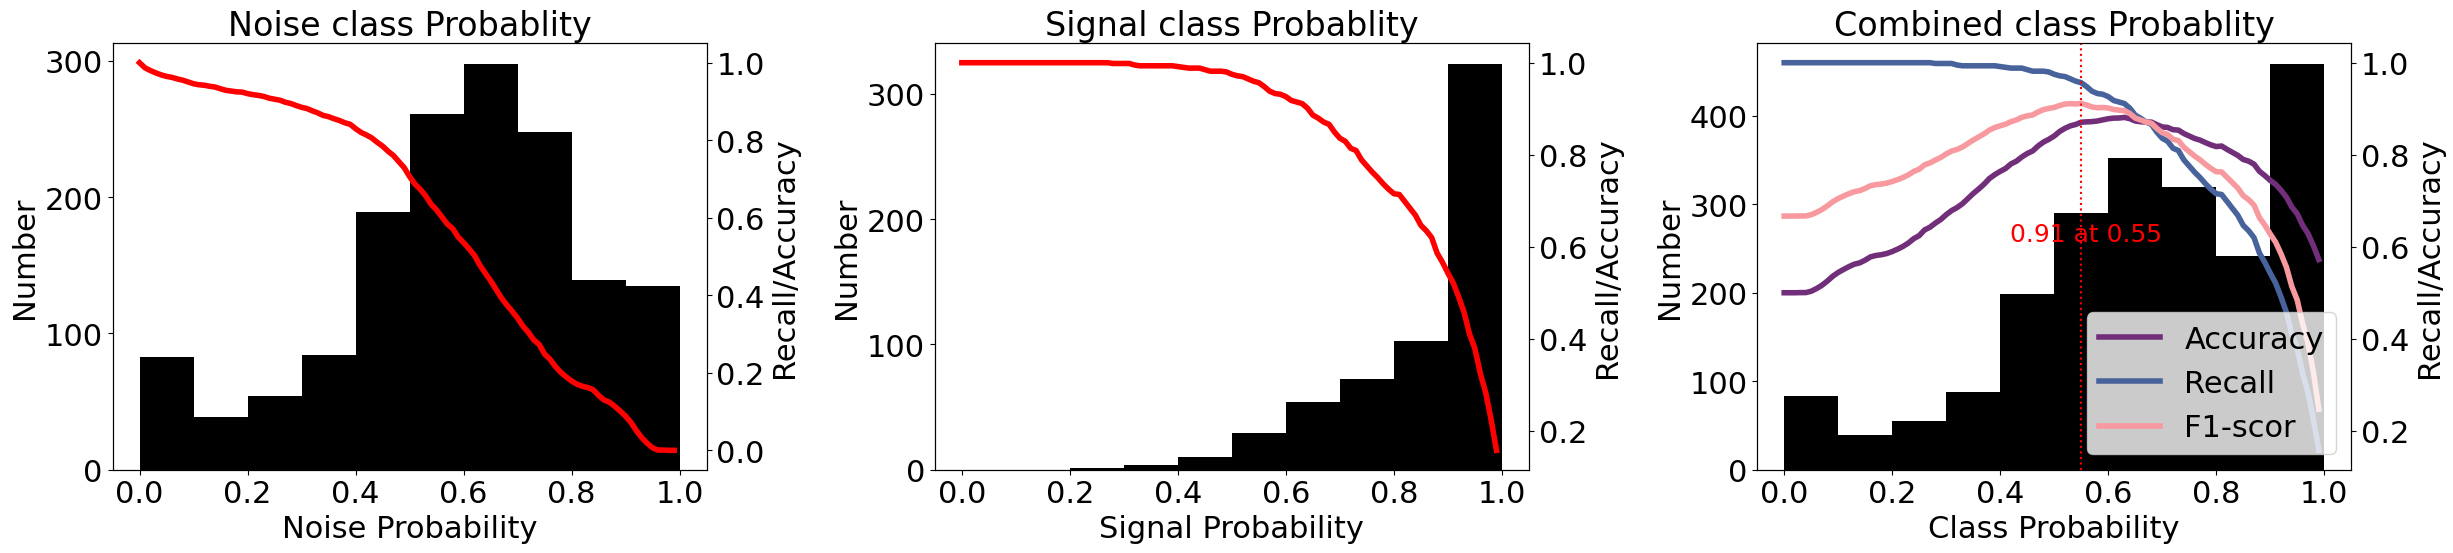

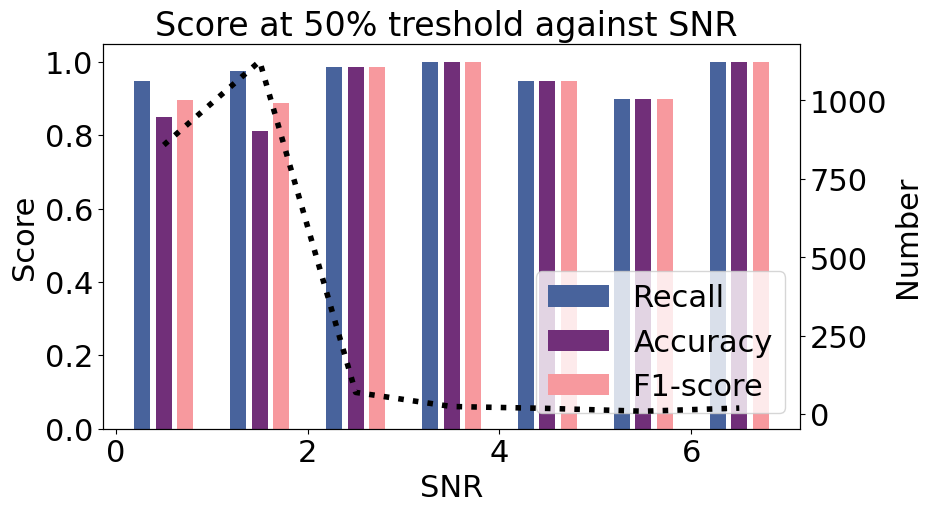

In [100]:
f1,f2, L = plotprobs(pred_list_Cred2,labels)
BestP2['Cred'] = L[0]
BestT2['Cred'] = L[1]
BestA2['Cred'] = L[3]
BestR2['Cred'] = L[2]
f1.savefig("Figure/CRED_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/CRED_Snr_GB.svg", dpi=100, bbox_inches='tight')

## EQTransformer

In [86]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [87]:

pred_list = []
tic()
for i in tqdm(range(len(datasetGB))):
    preds = model.annotate(datasetGB[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['EQT']=tac()
pred_list_EQT2 = np.array(pred_list)

100%|██████████| 2127/2127 [01:53<00:00, 18.72it/s]


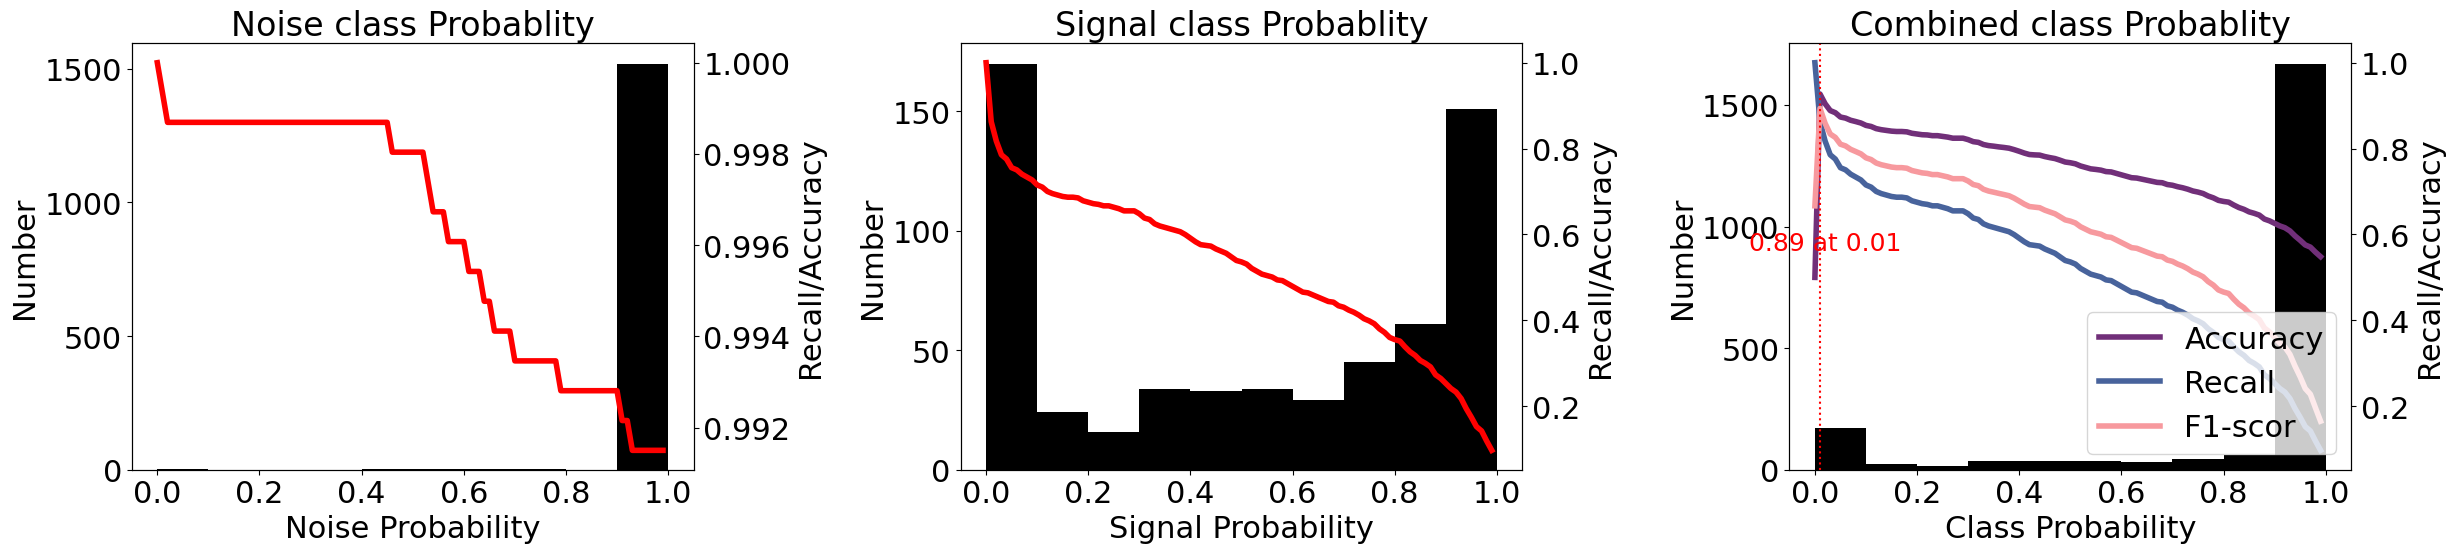

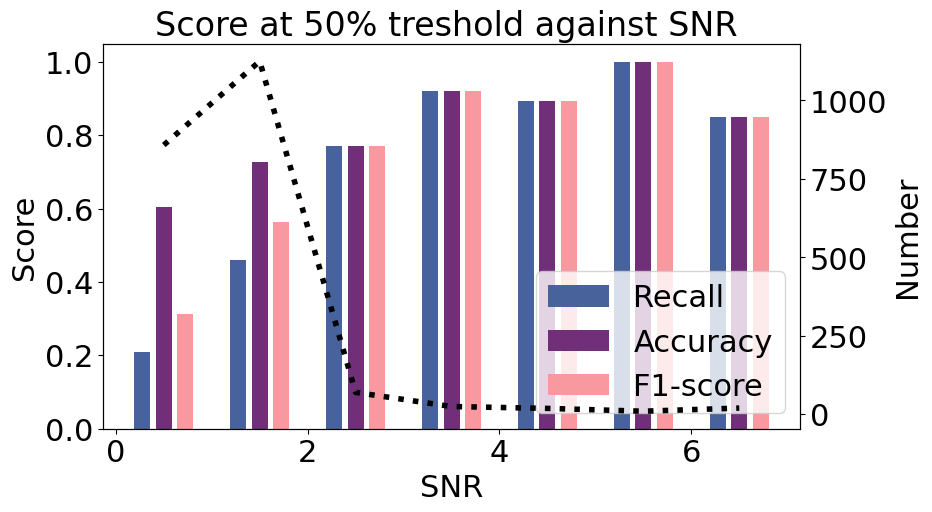

In [88]:
f1,f2, L = plotprobs(pred_list_EQT2,labels)
BestP2['EQT'] = L[0]
BestT2['EQT'] = L[1]
BestA2['EQT'] = L[3]
BestR2['EQT'] = L[2]
f1.savefig("Figure/EQT_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/EQT_Snr_GB.svg", dpi=100, bbox_inches='tight')

## GPD

In [91]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [92]:
pred_list = []
tic()
for i in tqdm(range(len(datasetGB))):
    preds = model.annotate(datasetGB[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['GPD']=tac()
pred_list_GPD2 = np.array(pred_list)

  0%|          | 0/2127 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
100%|██████████| 2127/2127 [11:58<00:00,  2.96it/s]


Task was destroyed but it is pending!
task: <Task pending name='Task-269289' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-269287' coro=<_async_in_context.<locals>.run_in_context() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:60> wait_for=<Task pending name='Task-269289' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>


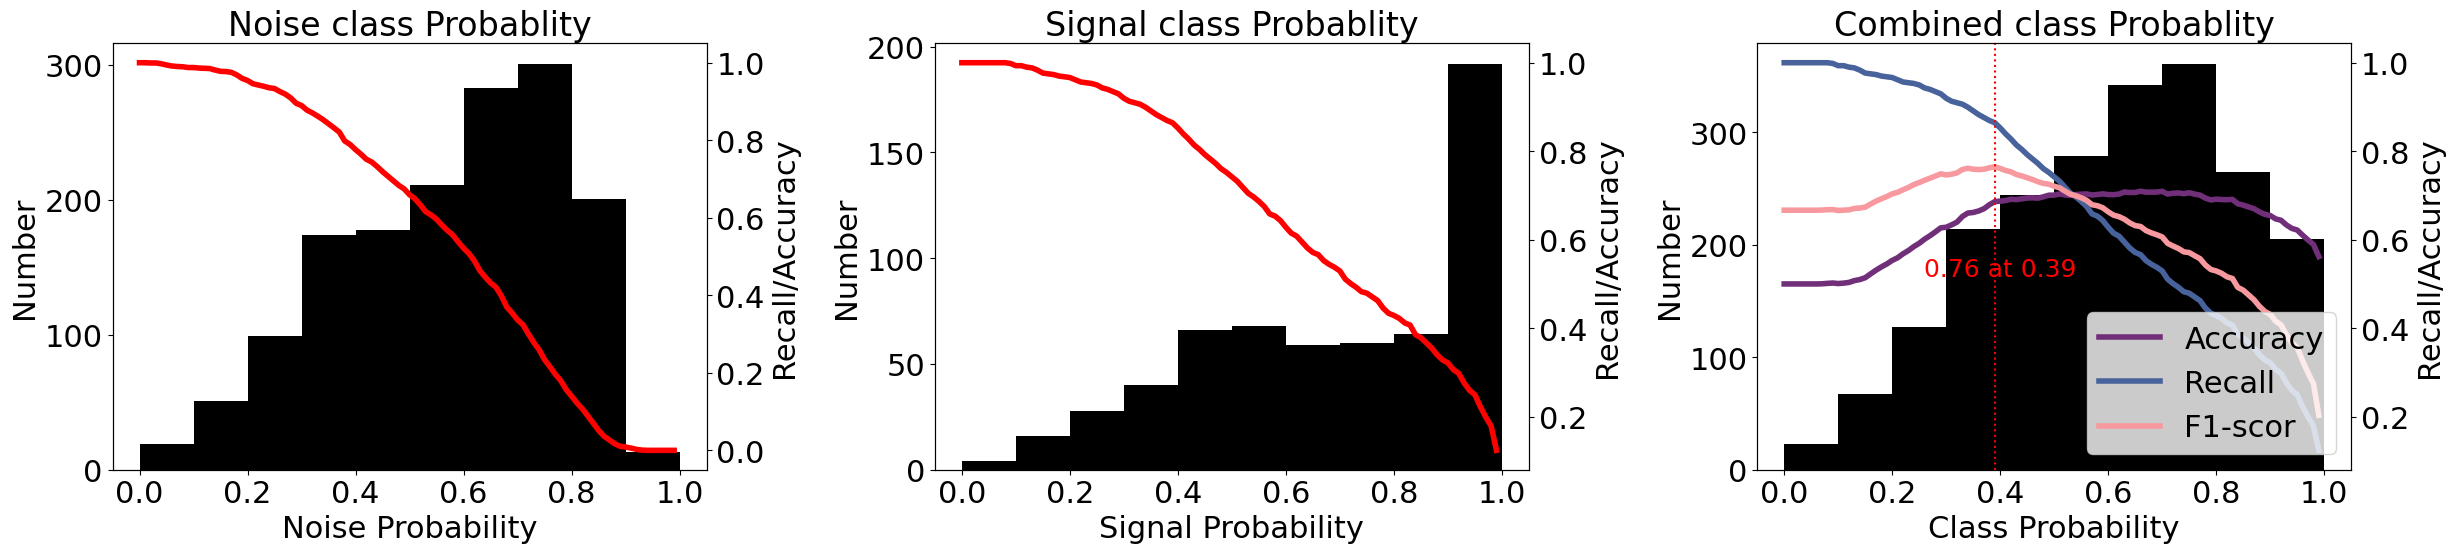

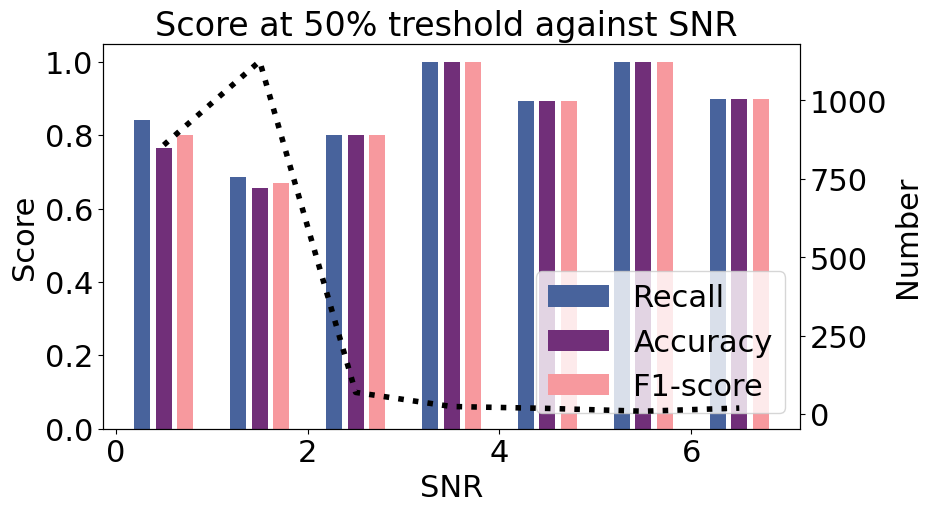

In [93]:
f1,f2, L = plotprobs(pred_list_GPD2,labels)
BestP2['GPD'] = L[0]
BestT2['GPD'] = L[1]
BestA2['GPD'] = L[3]
BestR2['GPD'] = L[2]
f1.savefig("Figure/GPD_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/GPD_Snr_GB.svg", dpi=100, bbox_inches='tight')

## PhaseNet

In [92]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [93]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(datasetGB))):
    preds = model.annotate(datasetGB[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['PhaseNet']=tac()
pred_list_phase2 = np.array(pred_list)

100%|██████████| 2127/2127 [00:18<00:00, 113.96it/s]


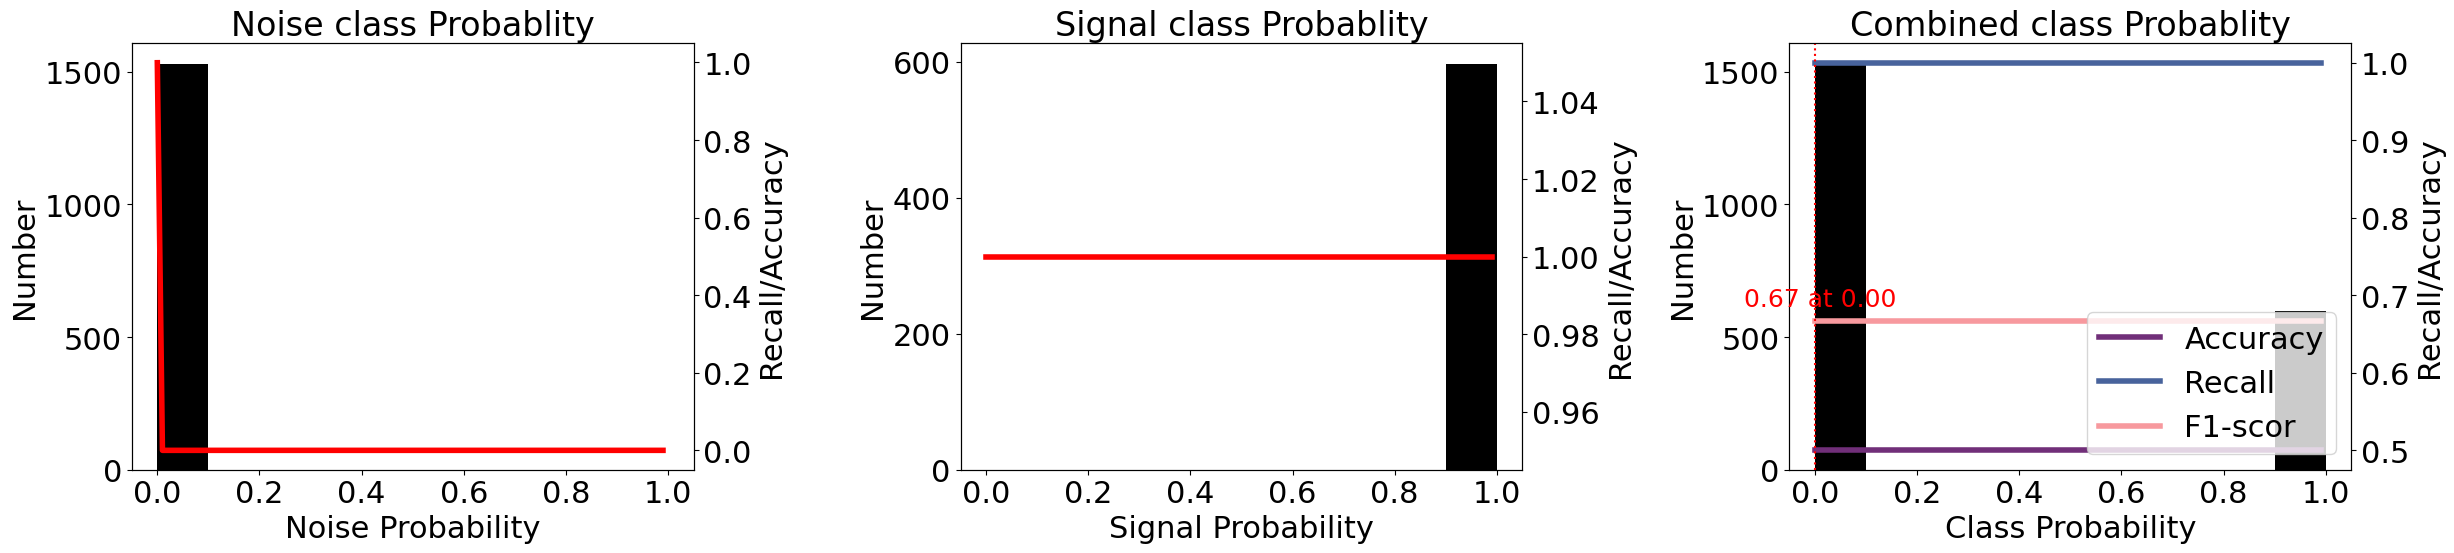

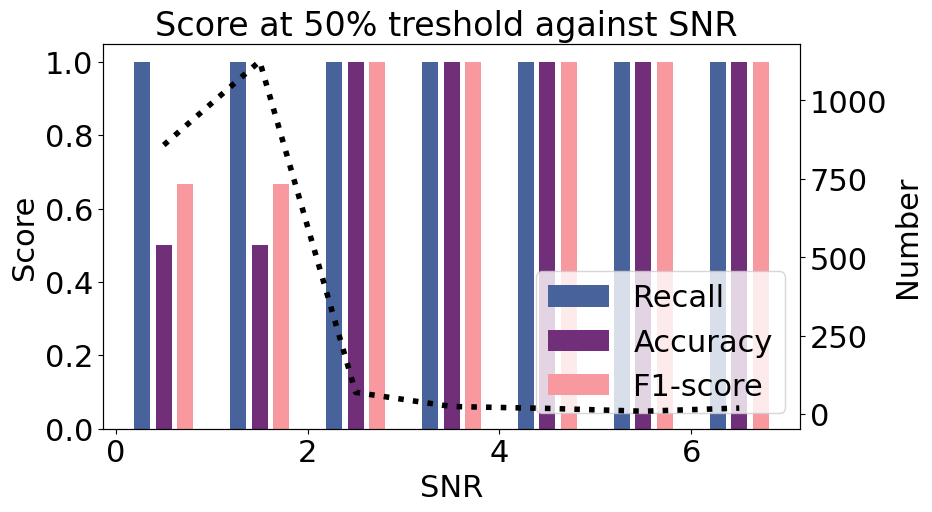

In [94]:
f1,f2, L = plotprobs(pred_list_phase2,labels)
BestP2['PhaseNet'] = L[0]
BestT2['PhaseNet'] = L[1]
BestA2['PhaseNet'] = L[3]
BestR2['PhaseNet'] = L[2]
f1.savefig("Figure/PhaseNet_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/PhaseNet_Snr_GB.svg", dpi=100, bbox_inches='tight')

## OBSTransformer

In [50]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [51]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(datasetGB))):
    preds = model.annotate(datasetGB[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['OBS'] = tac()
pred_list_OBS2 = np.array(pred_list)

  0%|          | 0/2127 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
  0%|          | 3/2127 [00:00<01:24, 25.24it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-119532' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-119534' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.

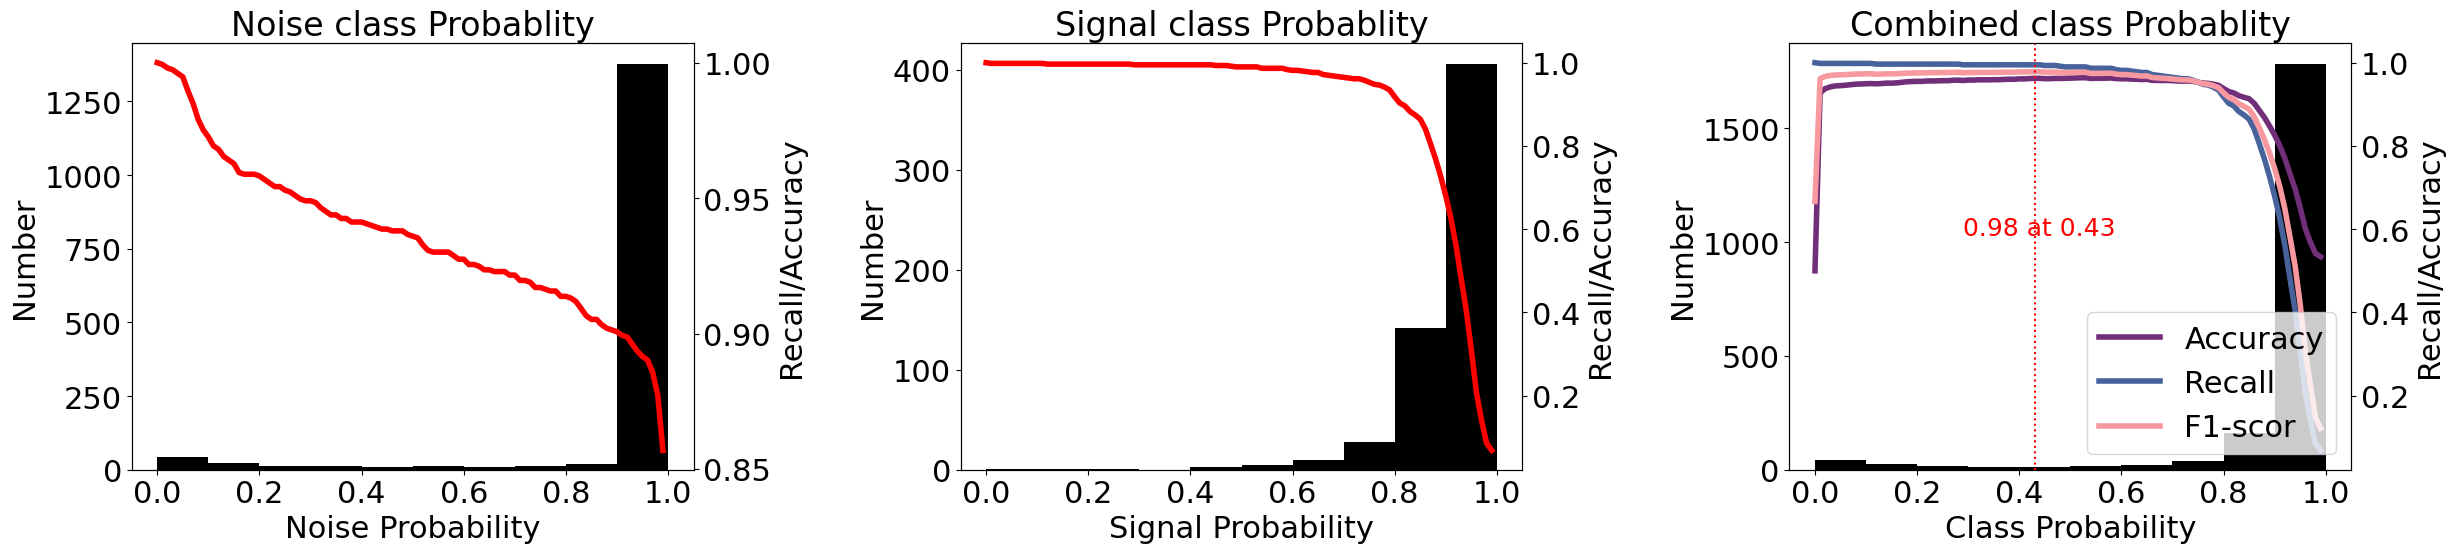

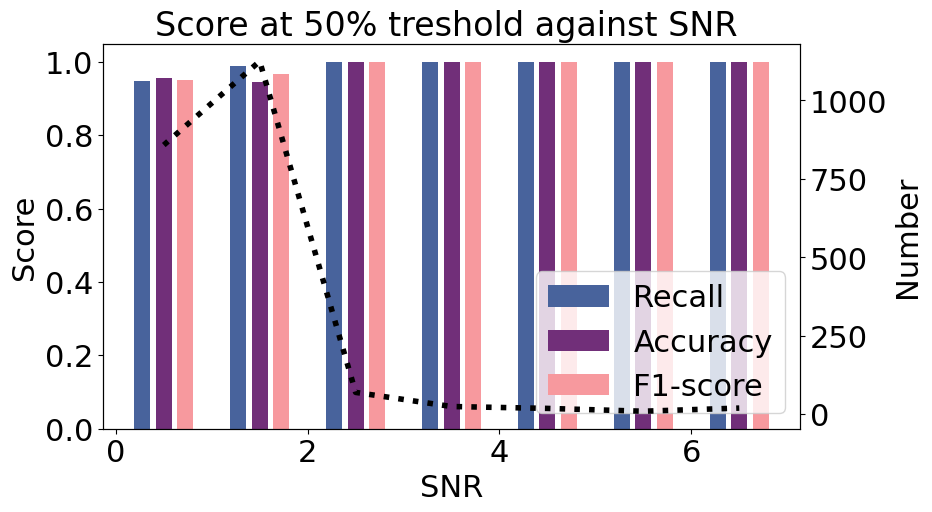

In [52]:
f1,f2, L = plotprobs(pred_list_OBS2,labels)
BestP2['OBS'] = L[0]
BestT2['OBS'] = L[1]
BestA2['OBS'] = L[3]
BestR2['OBS'] = L[2]
f1.savefig("Figure/OBST_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/OBST_Snr_GB.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE NoAE

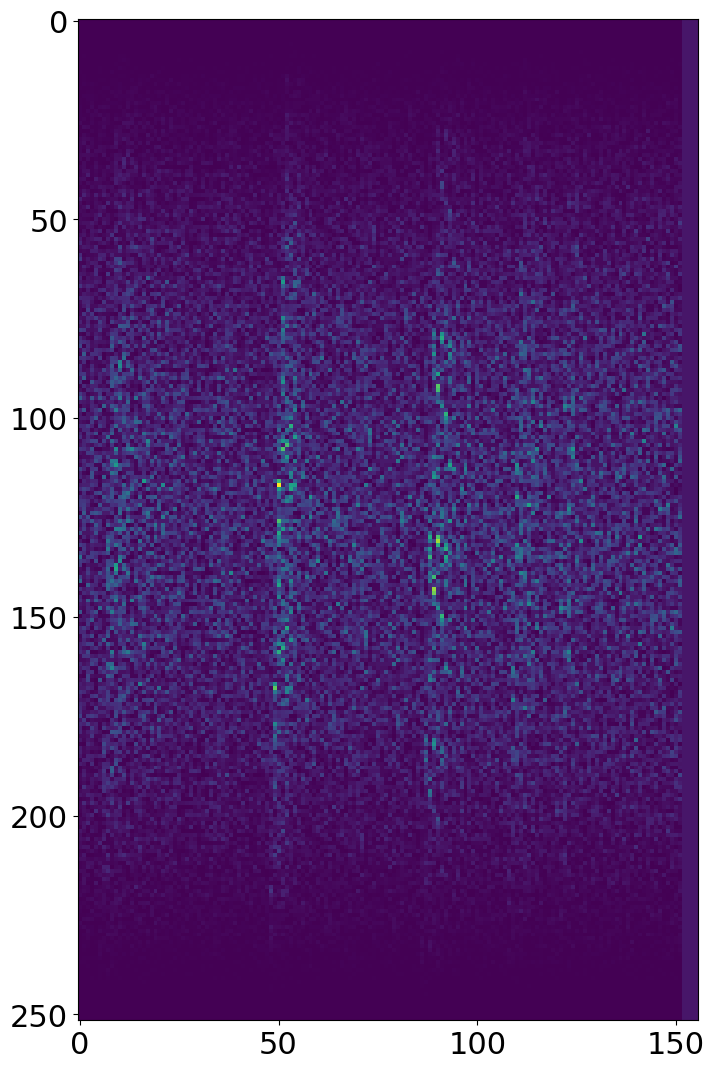

In [46]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [47]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [48]:
prob = []
tic()
for data in tqdm(dataset_IsAEGB):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
toc()
chrono['IsAE']= tac()
pred_lis_IsAE2 = np.array(prob)    

100%|██████████| 2127/2127 [00:03<00:00, 542.75it/s]


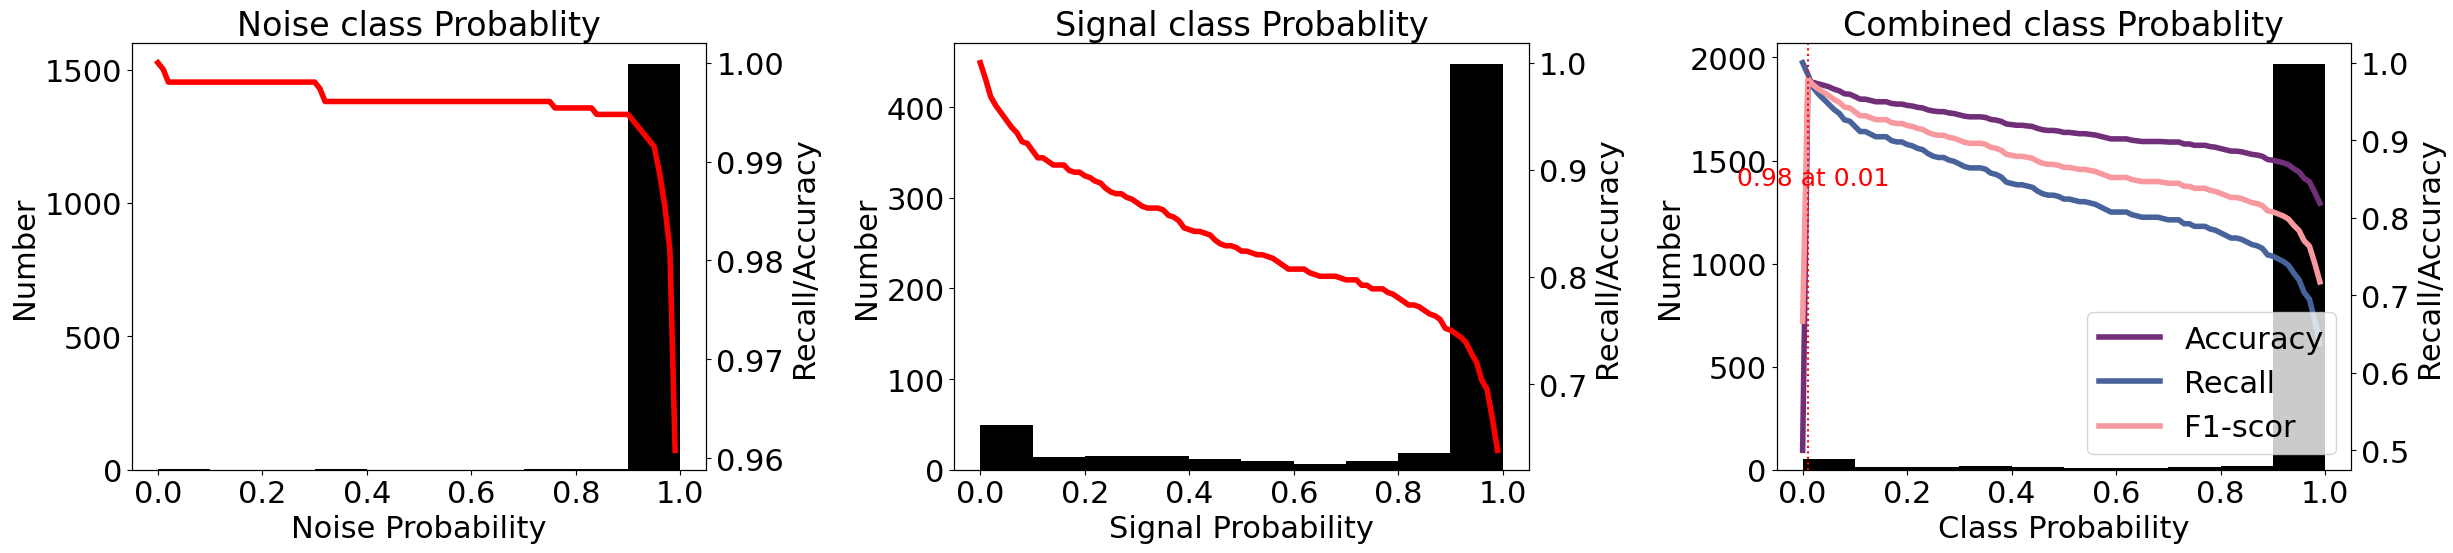

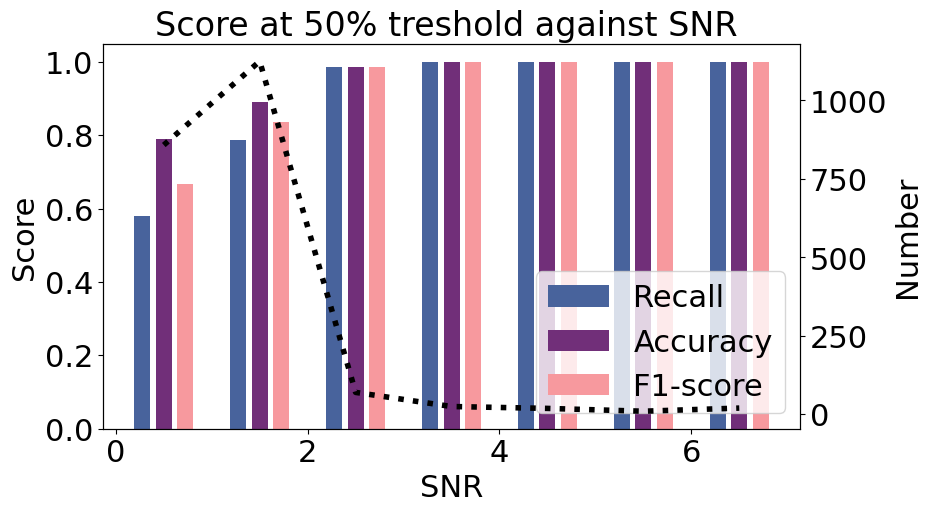

In [49]:
f1,f2, L = plotprobs(pred_lis_IsAE2,labels)
BestP2['IsAE'] = L[0]
BestT2['IsAE'] = L[1]
BestA2['IsAE'] = L[3]
BestR2['IsAE'] = L[2]
f1.savefig("Figure/IsAE_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAE_Snr_GB.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE MinUSil

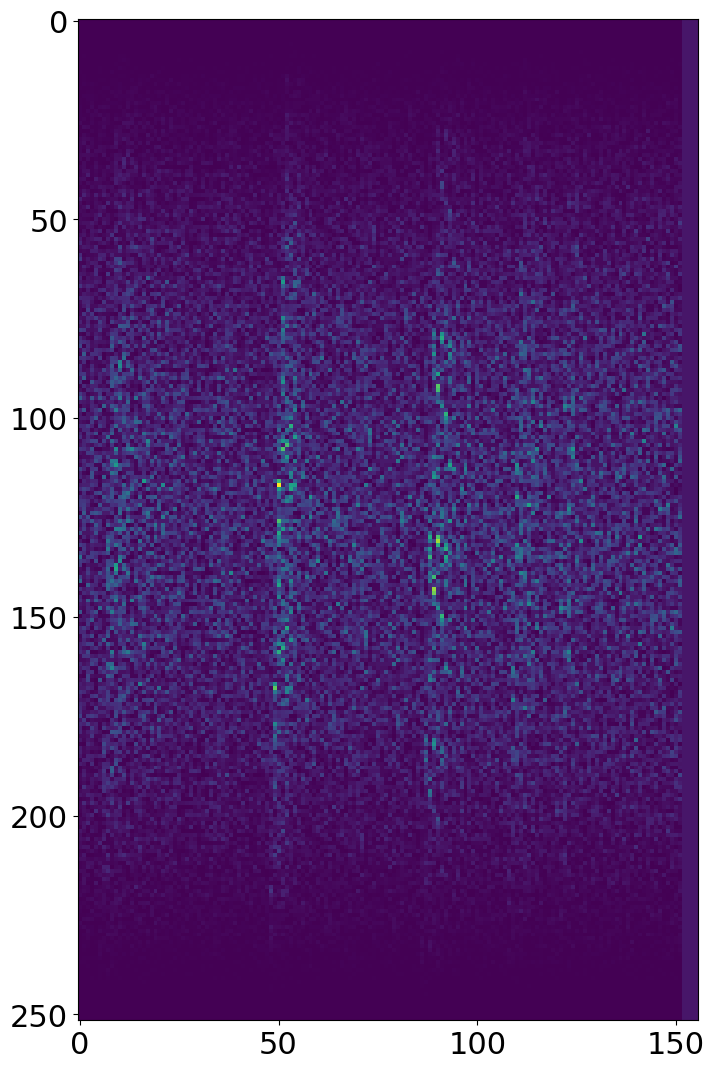

In [446]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [447]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_MAXPOOL_MINUSIL15.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [448]:
prob = []
tic()
for data in tqdm(dataset_IsAEGB):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
toc()
chrono['IsAEMIN']= tac()
pred_lis_IsAEMIN2 = np.array(prob)    

100%|██████████| 2127/2127 [00:03<00:00, 542.85it/s]


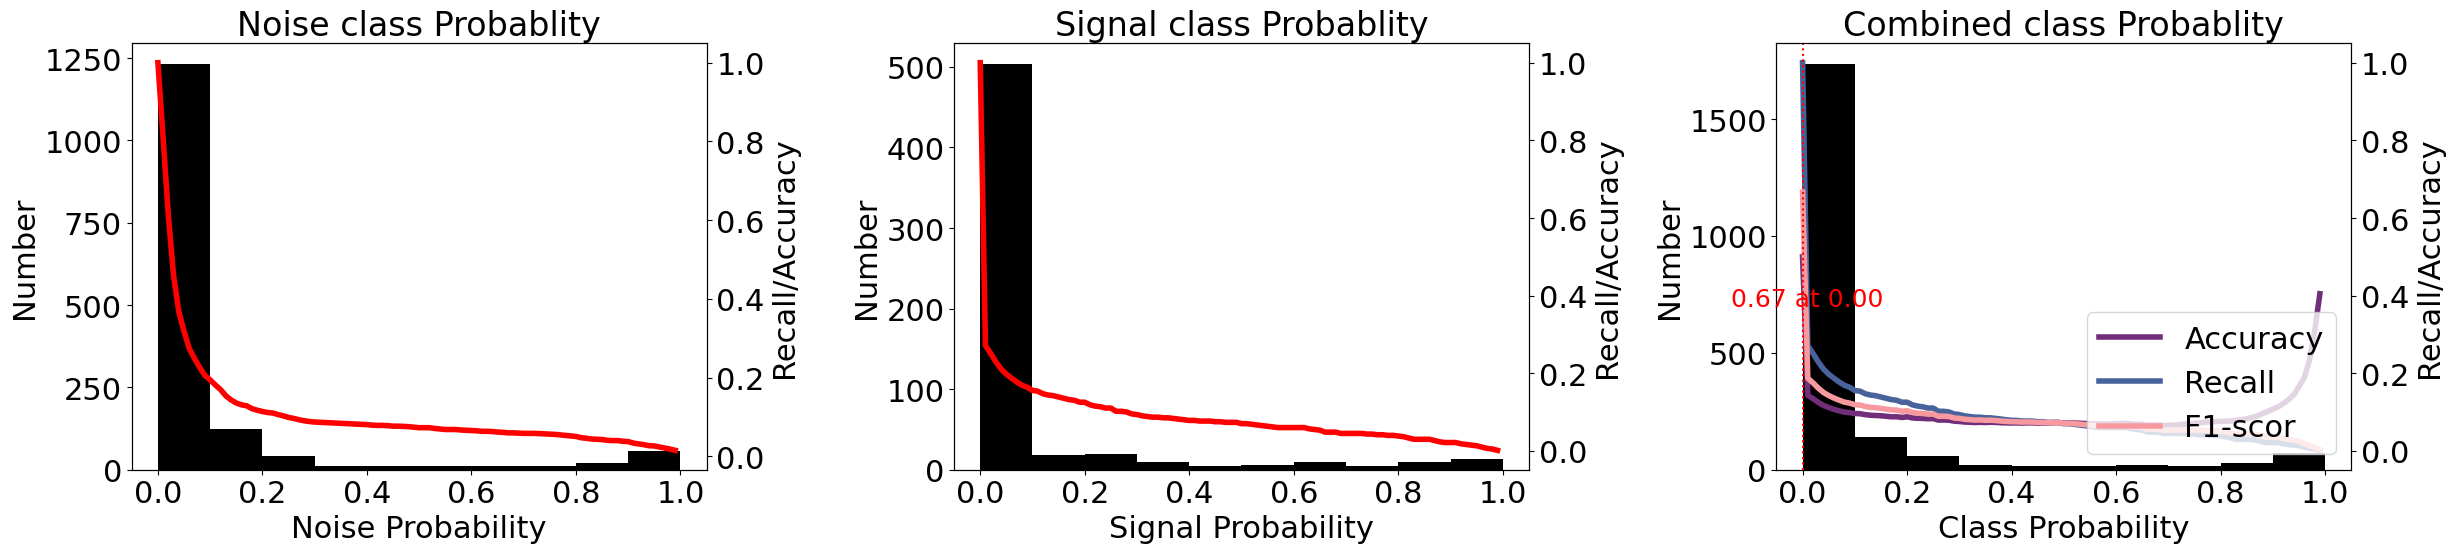

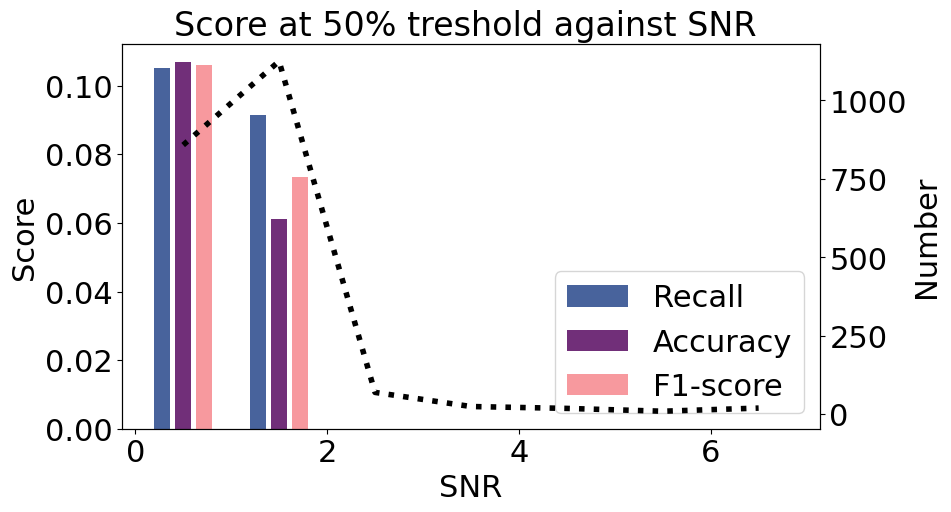

In [449]:
f1,f2, L = plotprobs(pred_lis_IsAEMIN2,labels)
BestP2['IsAEMIN'] = L[0]
BestT2['IsAEMIN'] = L[1]
BestA2['IsAEMIN'] = L[3]
BestR2['IsAEMIN'] = L[2]
f1.savefig("Figure/IsAEMIN_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAEMIN_Snr_GB.svg", dpi=100, bbox_inches='tight')

## Clock Figure

In [395]:
chrono2  = dict(sorted(chrono.items(), key=lambda item: item[1]))

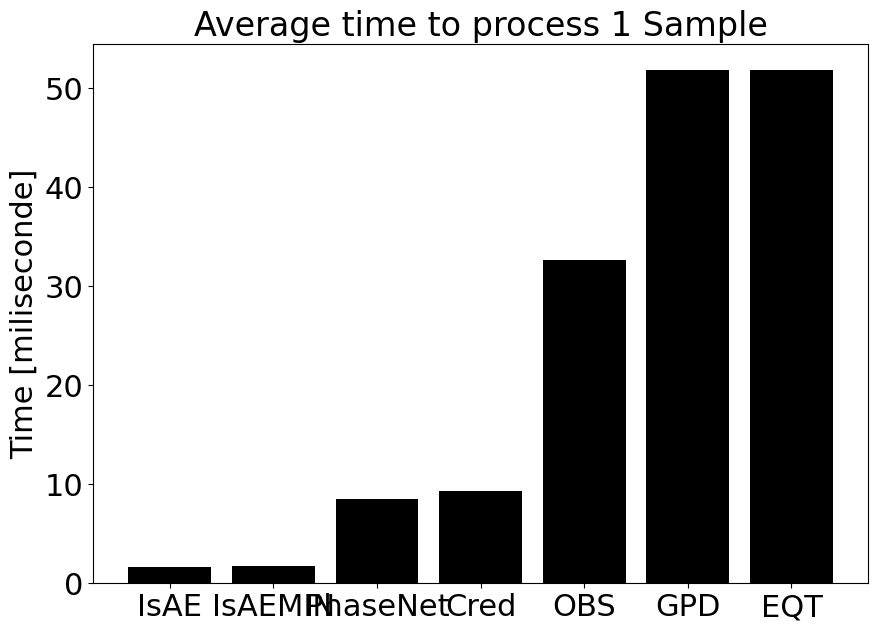

In [404]:
plt.figure(figsize=(10,7))
clocks_k = list(chrono2.keys())
plt.bar(clocks_k, [ chrono2[x]/len(dataset_IsAEMI)*1000 for x in clocks_k ],color='k' )
plt.ylabel('Time [miliseconde]')
plt.title('Average time to process 1 Sample')
plt.show()

# Testing on SeisBench Available Models and IsAE on MinUSil AENet Data

In [59]:
# Initialize dict
BestP3 ={}
BestT3 = {}
chrono3 = {}
BestA3 = {}
BestR3 = {}

## load data

In [83]:
file = 'dataset_Minusil_AENet'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    #paths = f['paths']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

MaxFrqsMin = np.array([max_frequency(w[0],10*1e6) for w in waveforms])
LabelMin = labels
print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(labels))

# Initialize the dataset For Natural Trained Earthquakes
datasetMI = CustomWaveformDataset_Seisbench(['']*len(labels), labels, ['']*len(labels), waveforms)
dataset_IsAEMI = CustomWaveformDataset_IsAE([''], labels, [''], waveforms,Spectrogram)

Dataset loaded from 'dataset_Minusil_AENet.h5'.
Number of elements :  6869


In [84]:
len(waveforms[0][0])

8000

In [85]:
print(datasetMI[0][0])  # Should be (3, num_samples) for 3-component data
print(datasetMI[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7f984e851670>, tensor(1))


## Cred

In [86]:
%autoawait on
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [87]:
pred_list = []
tic()
for i in tqdm(range(len(datasetMI))):
    preds = model.annotate(datasetMI[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono3['Cred']=tac()
pred_list_Cred3 = np.array(pred_list)

  0%|          | 0/6869 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-228055' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-228057' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]

In [ ]:
f1,f2, L = plotprobs(pred_list_Cred3,labels)
BestP3['Cred'] = L[0]
BestT3['Cred'] = L[1]
BestA3['Cred'] = L[3]
BestR3['Cred'] = L[2]
f1.savefig("Figure/CRED_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/CRED_Snr_MI.svg", dpi=100, bbox_inches='tight')

## EQTransformer

In [21]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [22]:

pred_list = []
tic()
for i in tqdm(range(len(datasetMI))):
    preds = model.annotate(datasetMI[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono3['EQT']=tac()
pred_list_EQT3 = np.array(pred_list)

 36%|███▌      | 2462/6869 [02:17<04:02, 18.19it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f72b0461000> is already entered
 78%|███████▊  | 5346/6869 [04:56<01:32, 16.40it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f72b0461000> is already entered
100%|██████████| 6869/6869 [06:24<00:00, 17.87it/s]


Task was destroyed but it is pending!
task: <Task pending name='Task-56154' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-56155' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-56155' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-73467' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septie

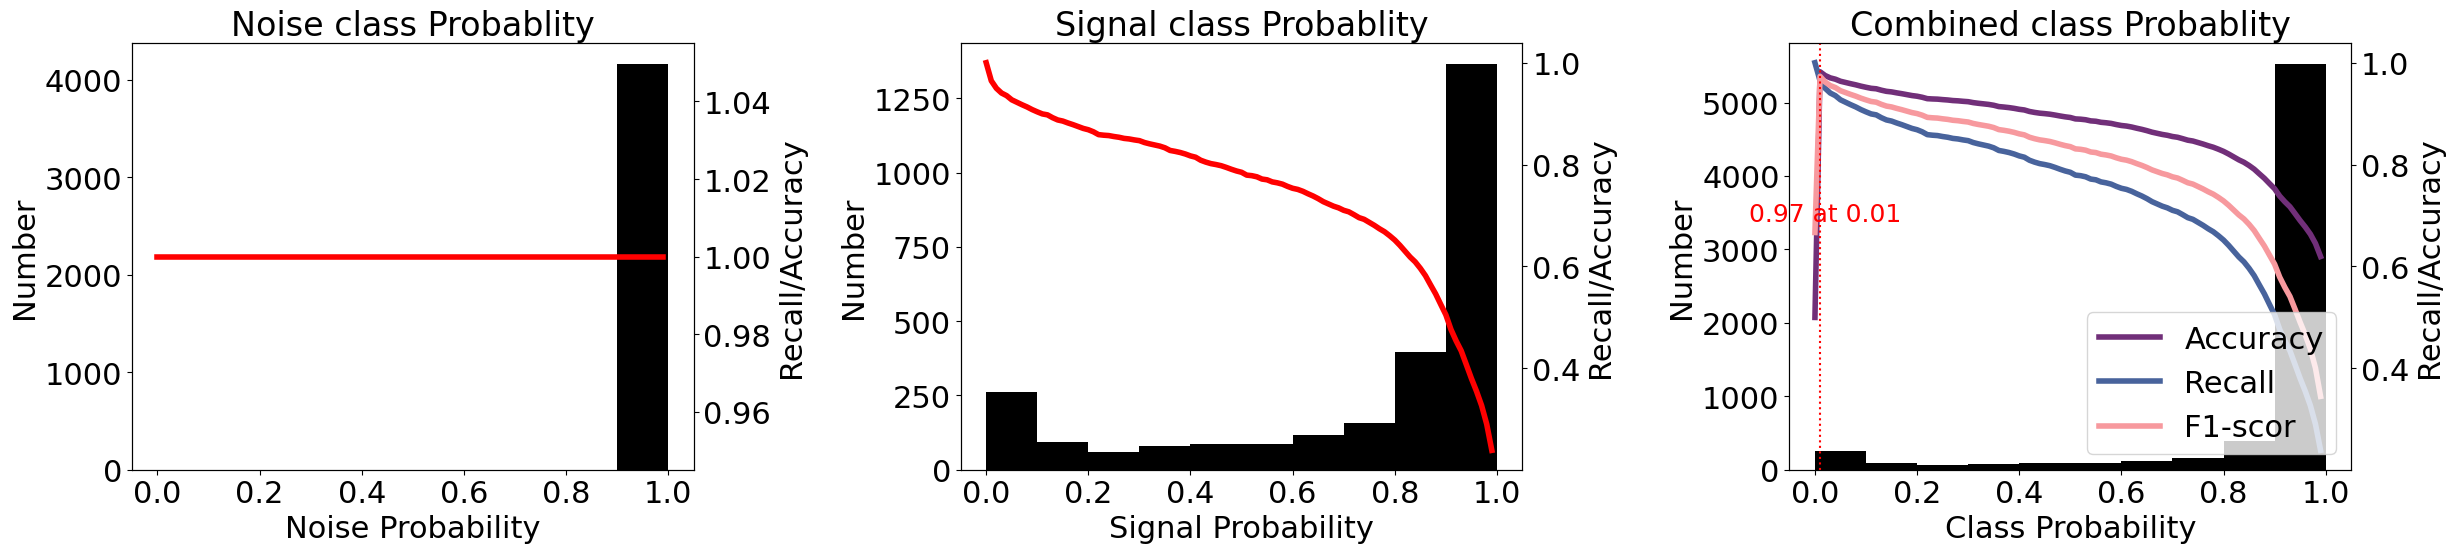

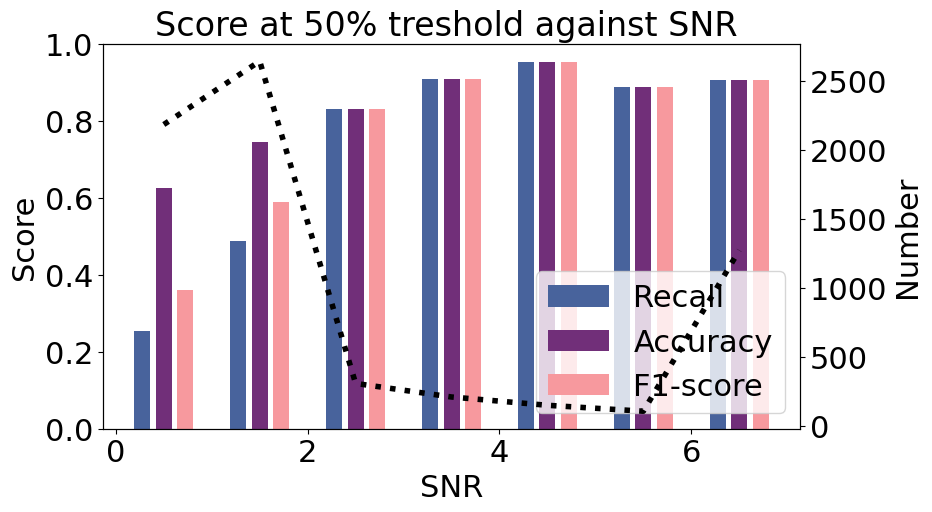

In [23]:
f1,f2, L = plotprobs(pred_list_EQT3,labels)
BestP3['EQT'] = L[0]
BestT3['EQT'] = L[1]
BestA3['EQT'] = L[3]
BestR3['EQT'] = L[2]
f1.savefig("Figure/EQT_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/EQT_Snr_MI.svg", dpi=100, bbox_inches='tight')

## GPD

In [24]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [25]:
pred_list = []
tic()
for i in tqdm(range(len(datasetMI))):
    preds = model.annotate(datasetMI[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono3['GPD']=tac()
pred_list_GPD3 = np.array(pred_list)

 80%|███████▉  | 5476/6869 [05:05<01:24, 16.43it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f72b0461000> is already entered
 80%|███████▉  | 5478/6869 [05:05<01:28, 15.77it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-115477' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-115478' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMar

Task was destroyed but it is pending!
task: <Task pending name='Task-115504' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-115505' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-115505' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-115525' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-se

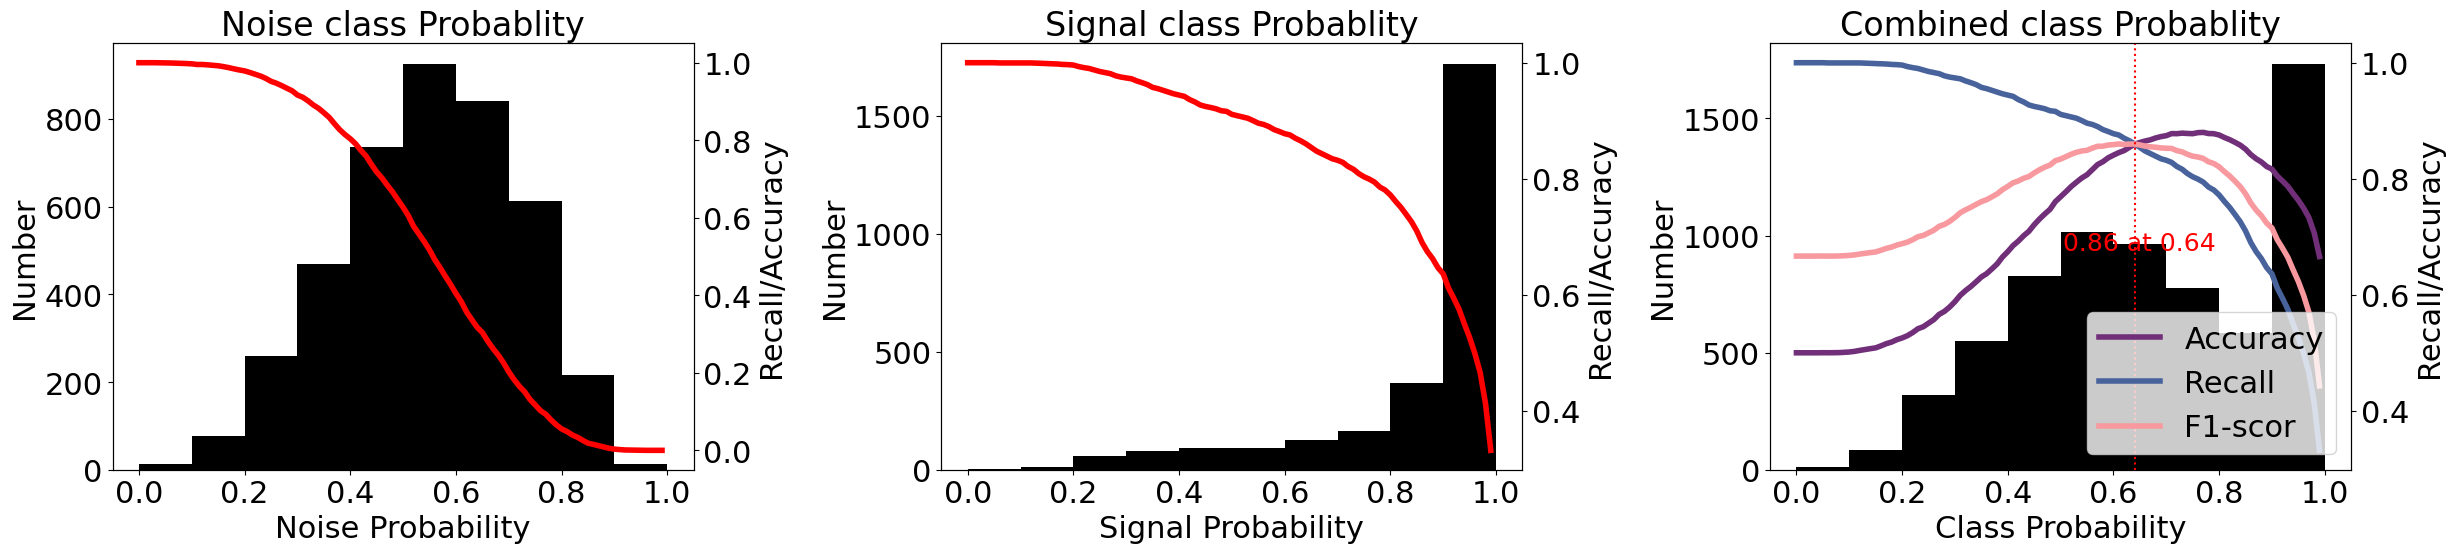

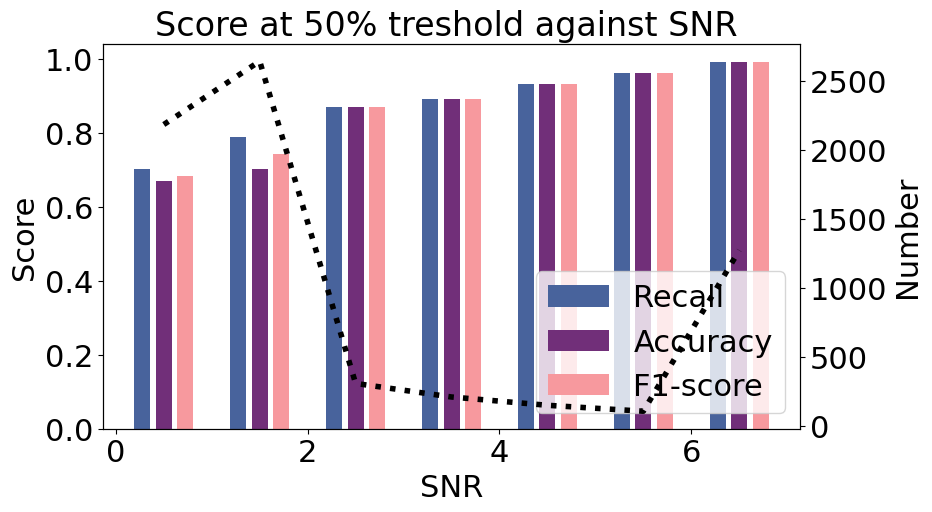

In [27]:
f1,f2, L = plotprobs(pred_list_GPD3,labels)
BestP3['GPD'] = L[0]
BestT3['GPD'] = L[1]
BestA3['GPD'] = L[3]
BestR3['GPD'] = L[2]
f1.savefig("Figure/GPD_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/GPD_Snr_MI.svg", dpi=100, bbox_inches='tight')

## PhaseNet

In [28]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [29]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(datasetMI))):
    preds = model.annotate(datasetMI[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono3['PhaseNet']=tac()
pred_list_phase3 = np.array(pred_list)

100%|██████████| 6869/6869 [00:59<00:00, 115.93it/s]


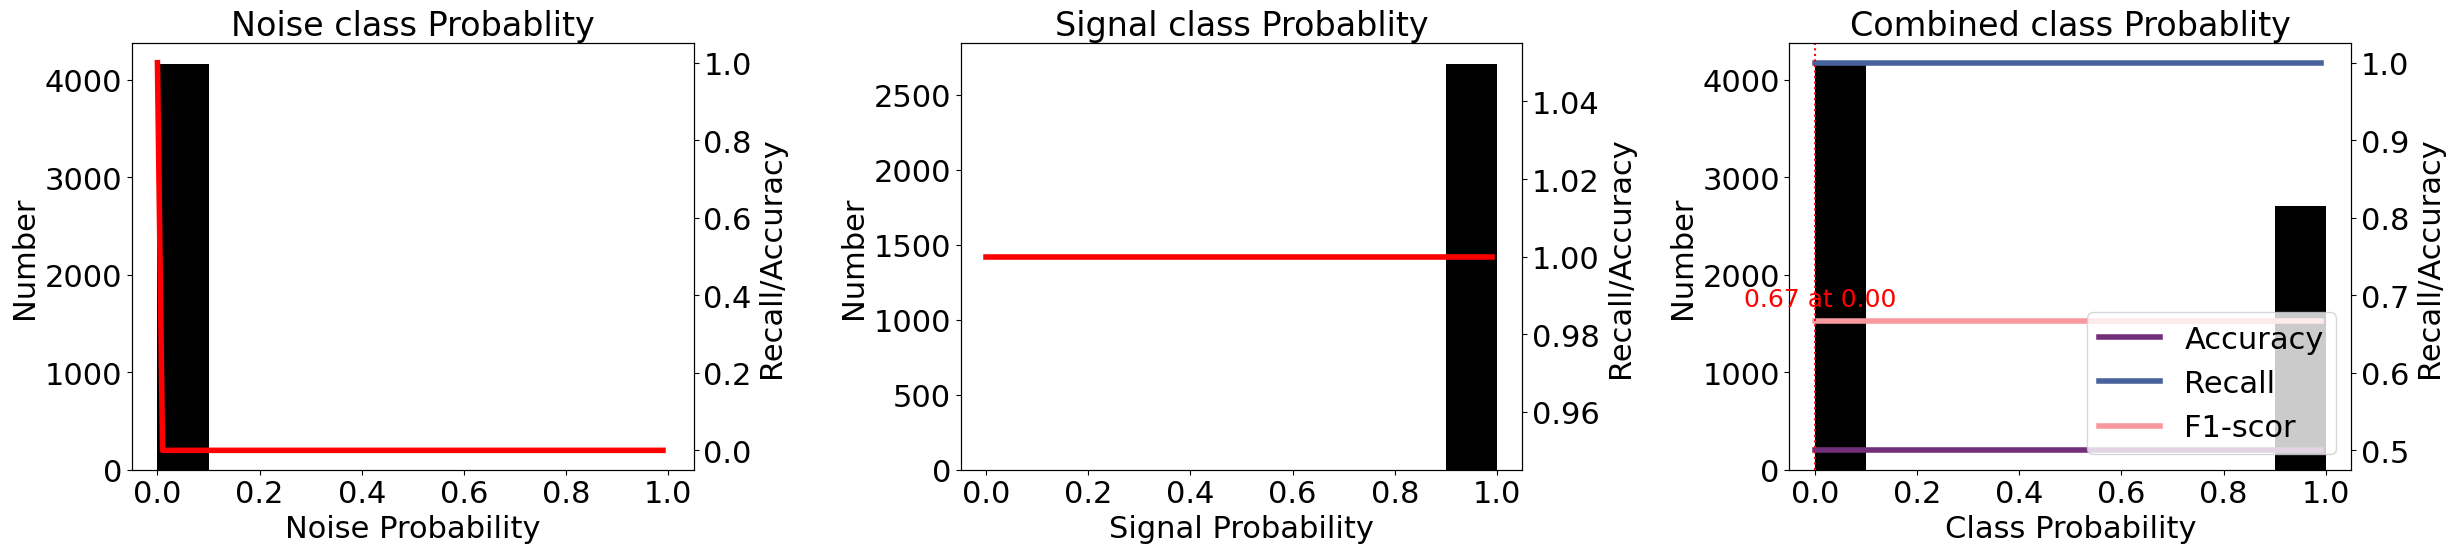

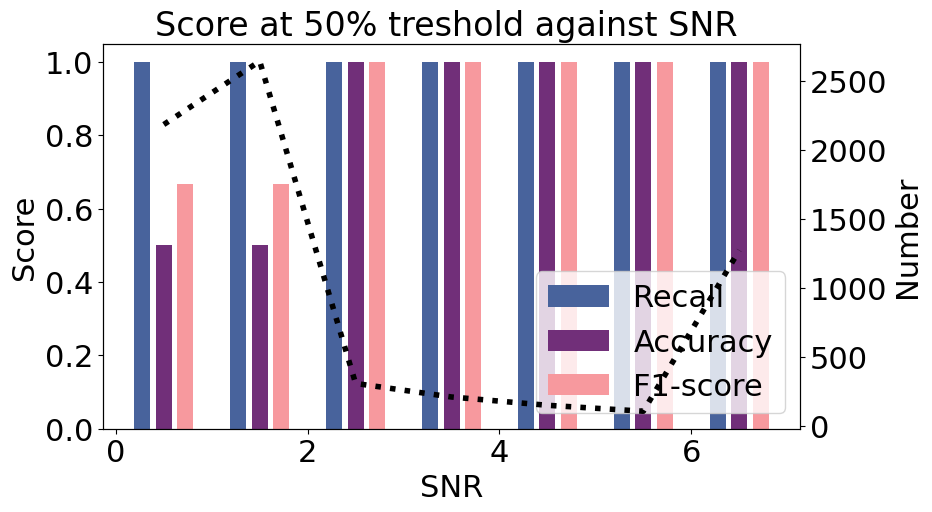

In [30]:
f1,f2, L = plotprobs(pred_list_phase3,labels)
BestP3['PhaseNet'] = L[0]
BestT3['PhaseNet'] = L[1]
BestA3['PhaseNet'] = L[3]
BestR3['PhaseNet'] = L[2]
f1.savefig("Figure/PhaseNet_Prob_GB.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/PhaseNet_Snr_GB.svg", dpi=100, bbox_inches='tight')

## OBSTransformer

In [67]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [68]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(datasetMI))):
    preds = model.annotate(datasetMI[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono3['OBS'] = tac()
pred_list_OBS3 = np.array(pred_list)

  0%|          | 0/6869 [00:00<?, ?it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7f9baf4c1980> is already entered
  0%|          | 2/6869 [00:00<06:16, 18.25it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-132352' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-132354' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.

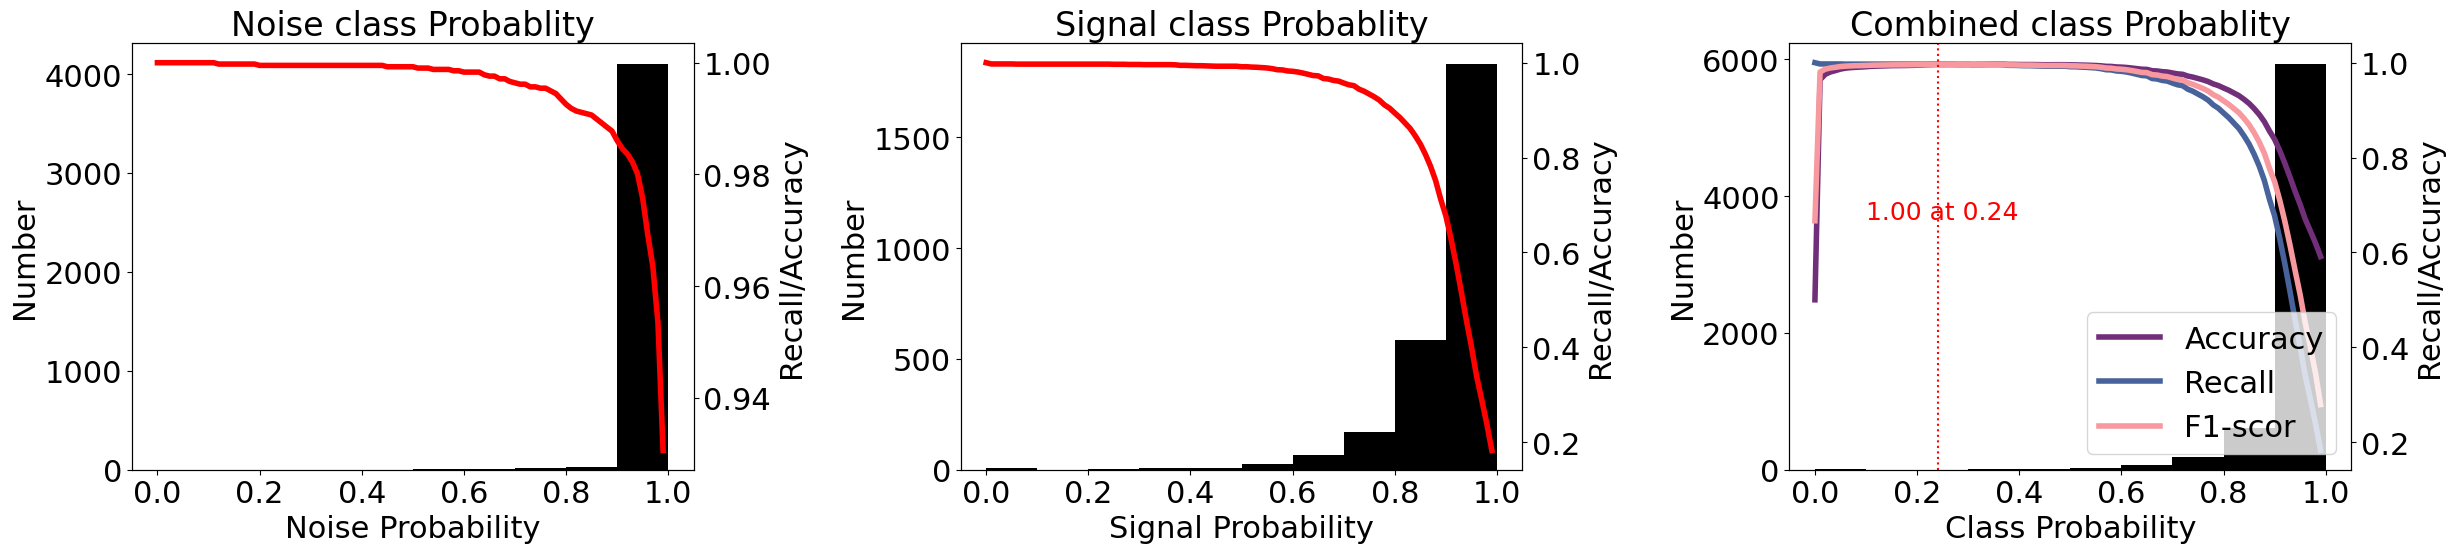

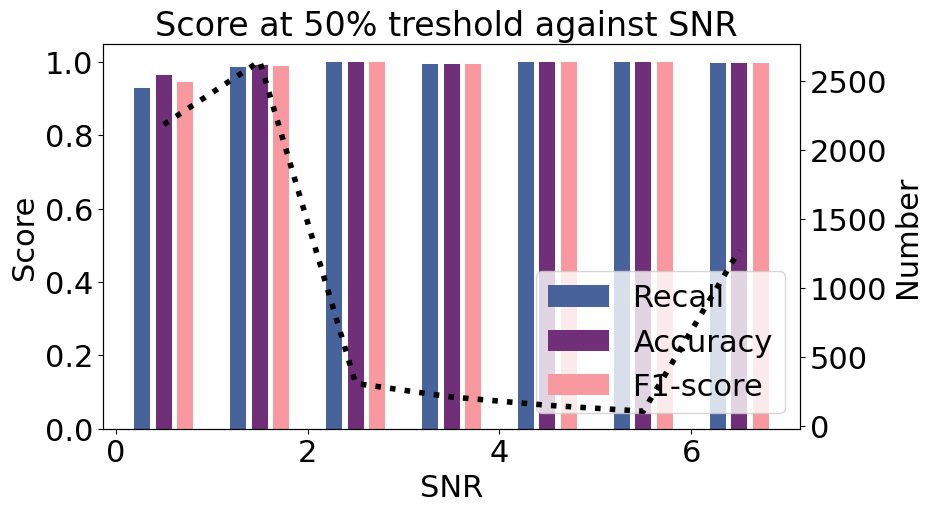

In [69]:
f1,f2, L = plotprobs(pred_list_OBS3,labels)
BestP3['OBS'] = L[0]
BestT3['OBS'] = L[1]
BestA3['OBS'] = L[3]
BestR3['OBS'] = L[2]
f1.savefig("Figure/OBST_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/OBST_Snr_MI.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE

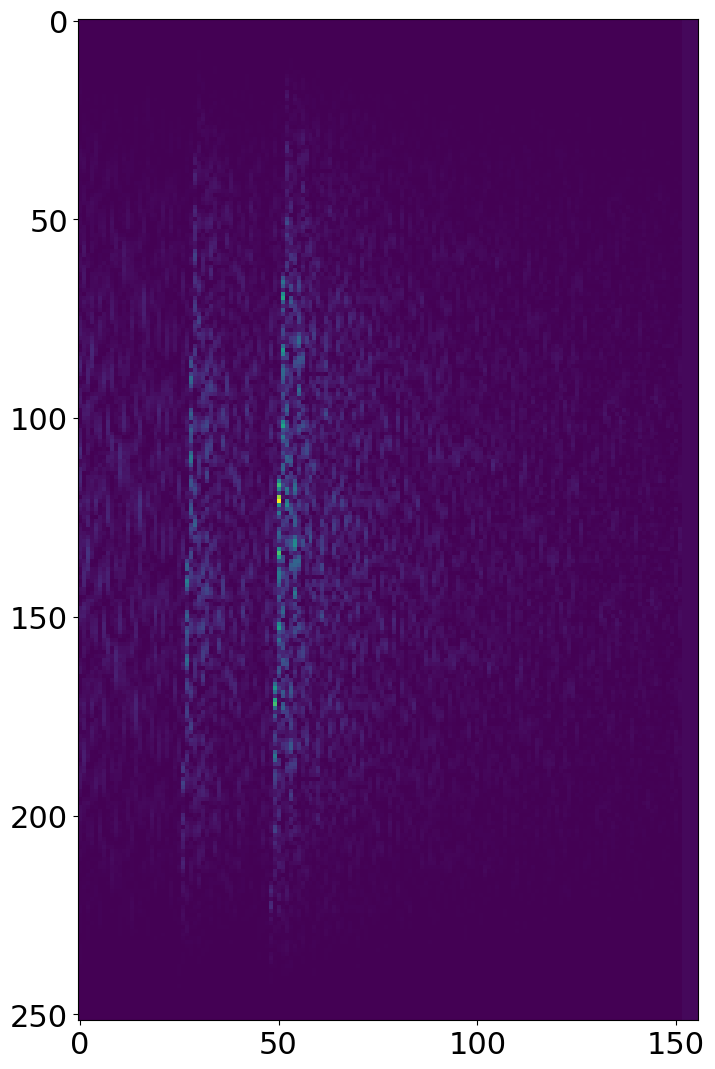

In [63]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [64]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [65]:
prob = []
tic()
for data in tqdm(dataset_IsAEMI):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
toc()
chrono3['IsAE']= tac()
pred_lis_IsAE3 = np.array(prob)    

6869it [00:11, 607.78it/s]           


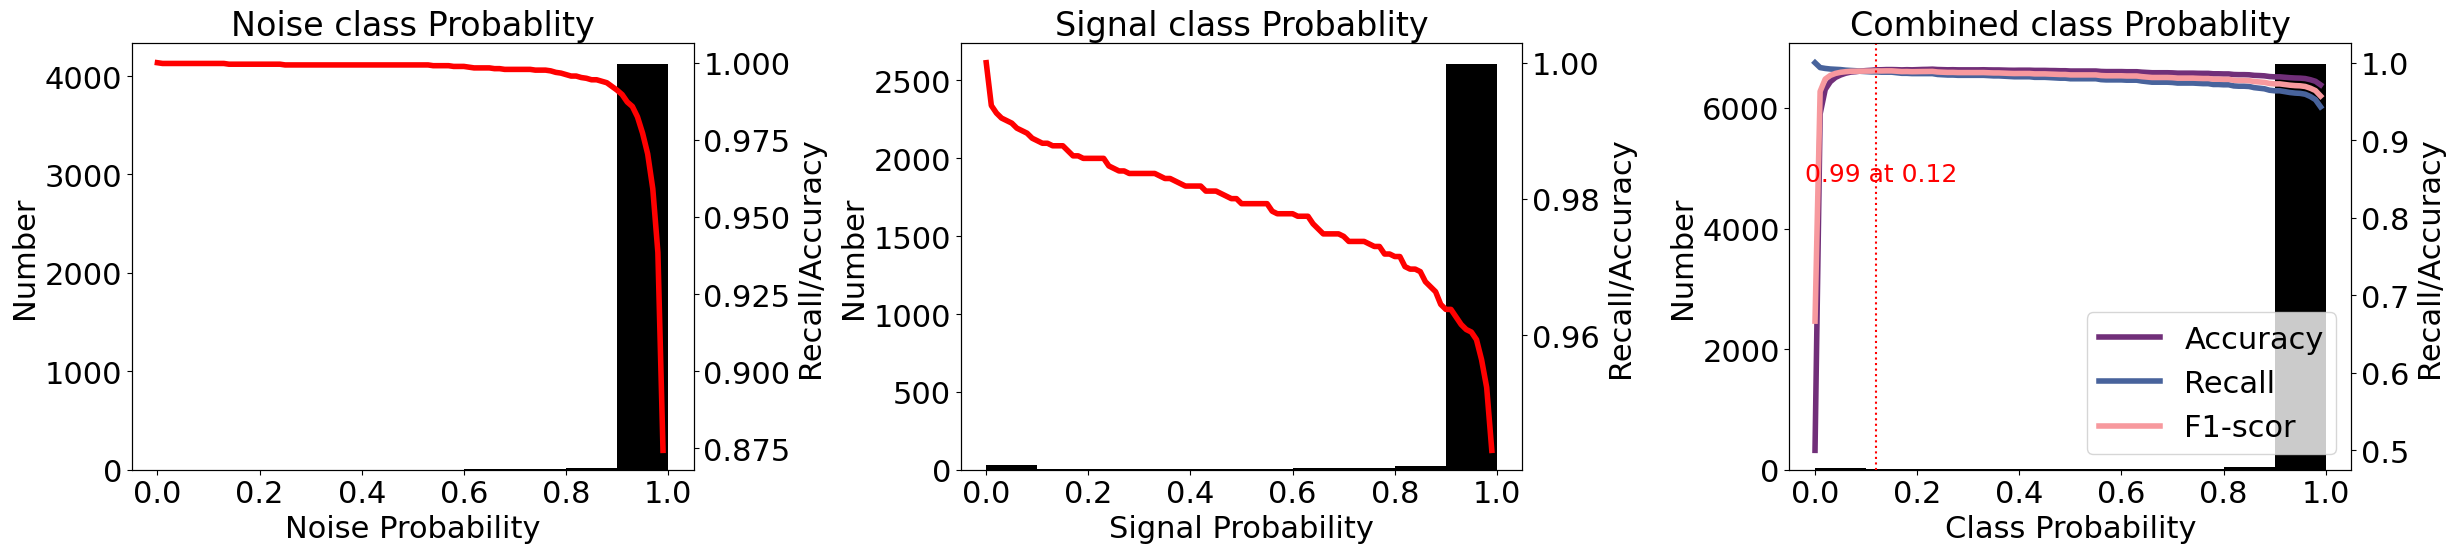

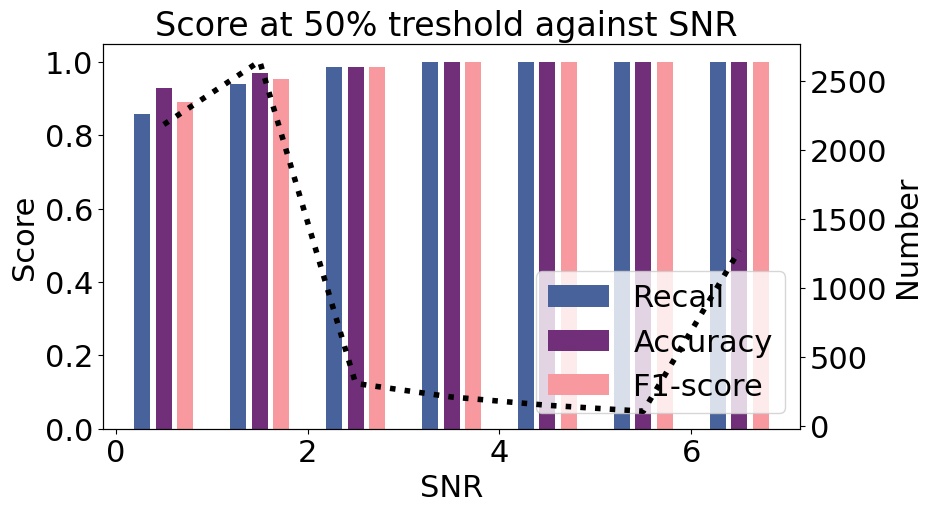

In [66]:
f1,f2, L = plotprobs(pred_lis_IsAE3,labels)
BestP3['IsAE'] = L[0]
BestT3['IsAE'] = L[1]
BestA3['IsAE'] = L[3]
BestR3['IsAE'] = L[2]
f1.savefig("Figure/IsAE_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAE_Snr_MI.svg", dpi=100, bbox_inches='tight')

## TESTING IsAE MinUSil

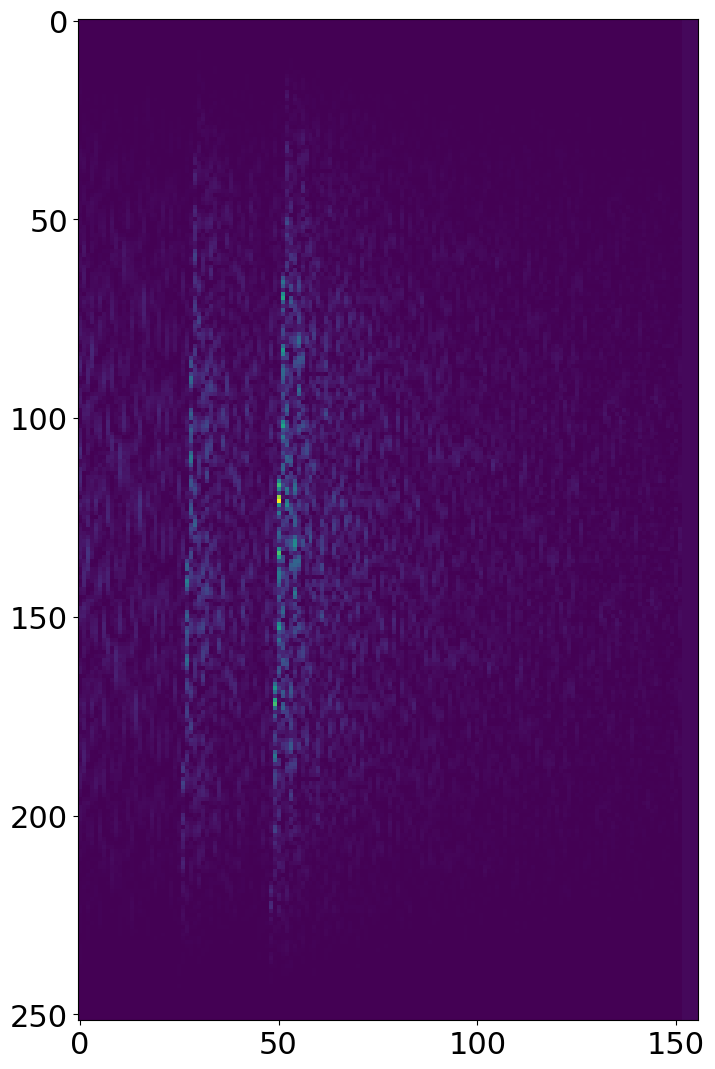

In [466]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [467]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_MAXPOOL_MINUSIL15.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [468]:
prob = []
tic()
for data in tqdm(dataset_IsAEMI):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
toc()
#chrono['IsAEMIN']= tac()
pred_lis_IsAEMIN3 = np.array(prob)    

6869it [00:11, 608.81it/s]                          


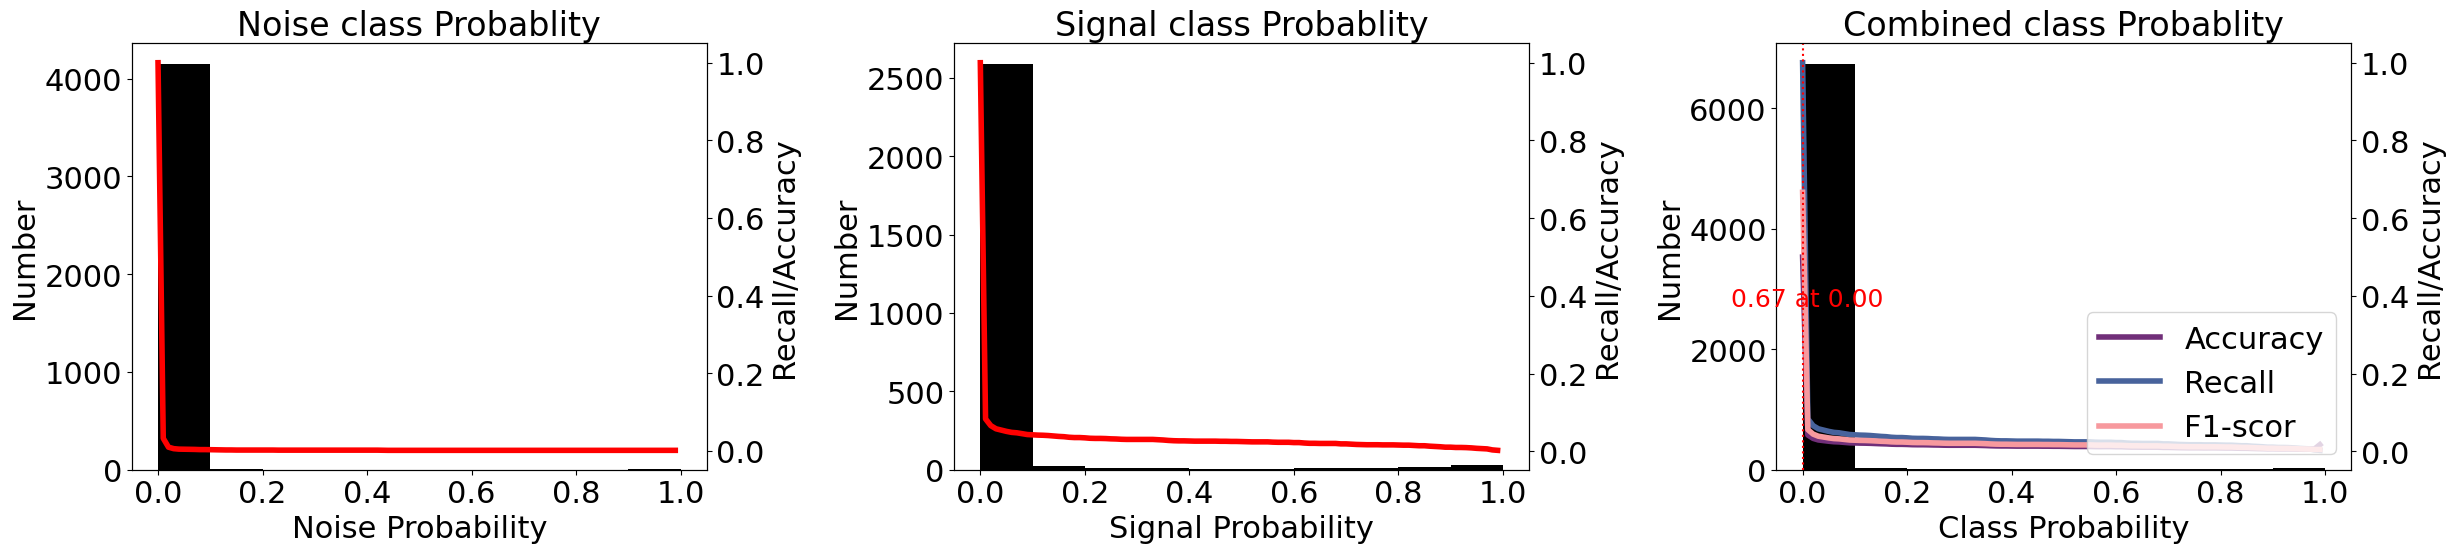

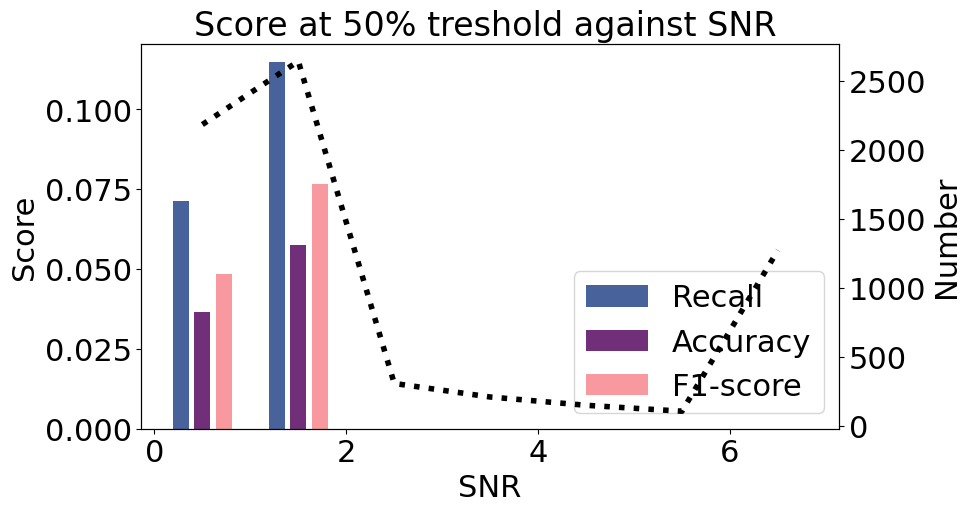

In [469]:
f1,f2, L = plotprobs(pred_lis_IsAEMIN3,labels)
BestP3['IsAEMIN'] = L[0]
BestT3['IsAEMIN'] = L[1]
BestA3['IsAEMIN'] = L[3]
BestR3['IsAEMIN'] = L[2]
f1.savefig("Figure/IsAEMIN_Prob_MI.svg", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAEMIN_Snr_MI.svg", dpi=100, bbox_inches='tight')

## Clock Figure

In [41]:
chrono3  = dict(sorted(chrono3.items(), key=lambda item: item[1]))

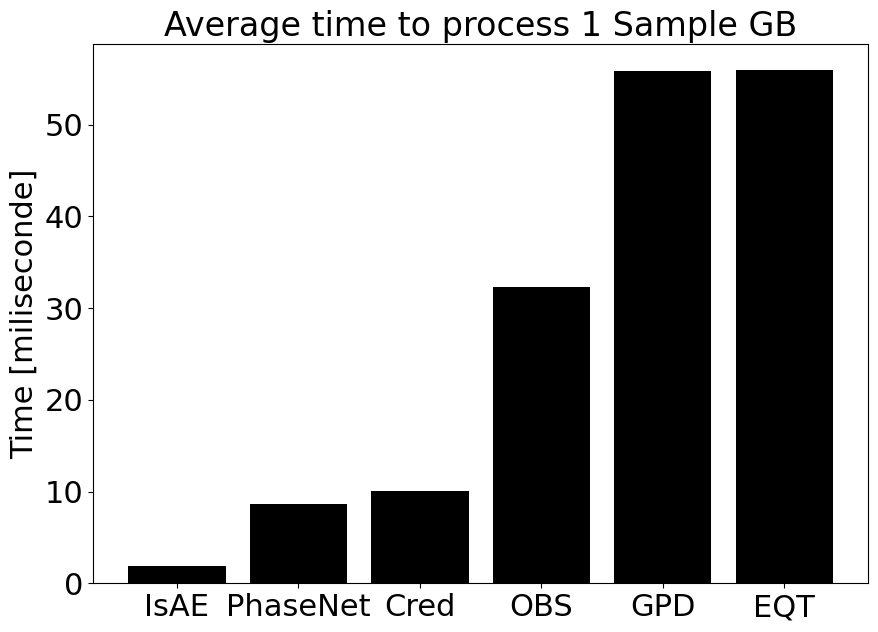

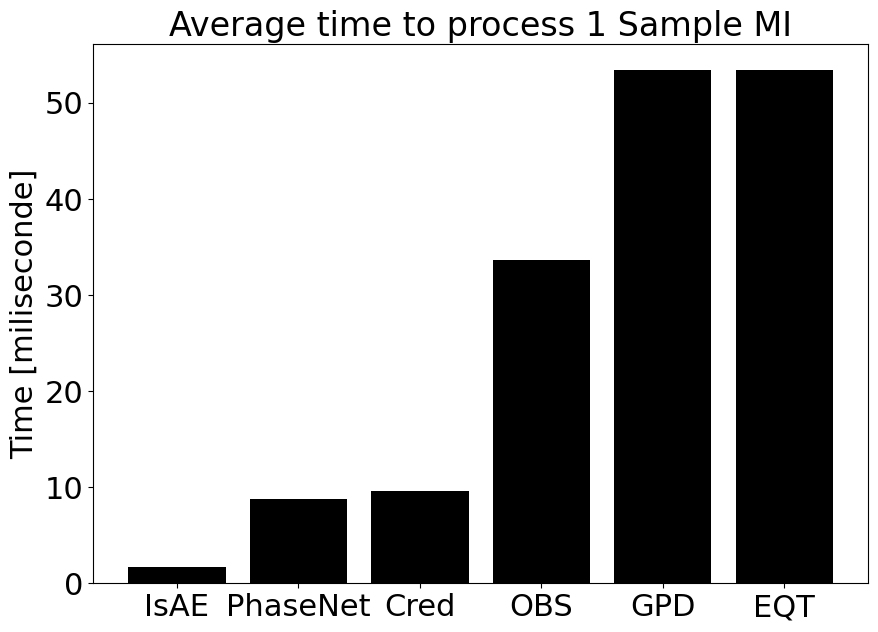

In [361]:
plt.figure(figsize=(10,7))
clocks_k = list(chrono3.keys())
plt.bar(clocks_k, [ chrono3[x]/len(pred_lis_IsAE3)*1000 for x in clocks_k],color='k' )
plt.ylabel('Time [miliseconde]')
plt.title('Average time to process 1 Sample GB')
plt.show()

plt.figure(figsize=(10,7))
clocks_k = list(chrono2.keys())
plt.bar(clocks_k, [ chrono2[x]/len(pred_lis_IsAE2)*1000 for x in clocks_k],color='k' )
plt.ylabel('Time [miliseconde]')
plt.title('Average time to process 1 Sample MI')
plt.savefig('Figure/Time.svg', format='SVG', dpi=200, bbox_inches='tight')
plt.show()

# Freq Test

In [101]:
MaxFreqs= np.concatenate((MaxFrqsOD, MaxFrqsGB,MaxFrqsMin), axis=0)
Labels = np.concatenate((LabelOD,LabelGB ,LabelMin), axis=0)

pred_list_OBS13= np.concatenate((pred_list_OBS1,pred_list_OBS2,pred_list_OBS3), axis=0)
pred_list_IsAE13= np.concatenate((pred_list_IsAE1,pred_lis_IsAE2,pred_lis_IsAE3), axis=0)
pred_list_Cred13= np.concatenate((pred_list_Cred1,pred_list_Cred2,pred_list_Cred3), axis=0)

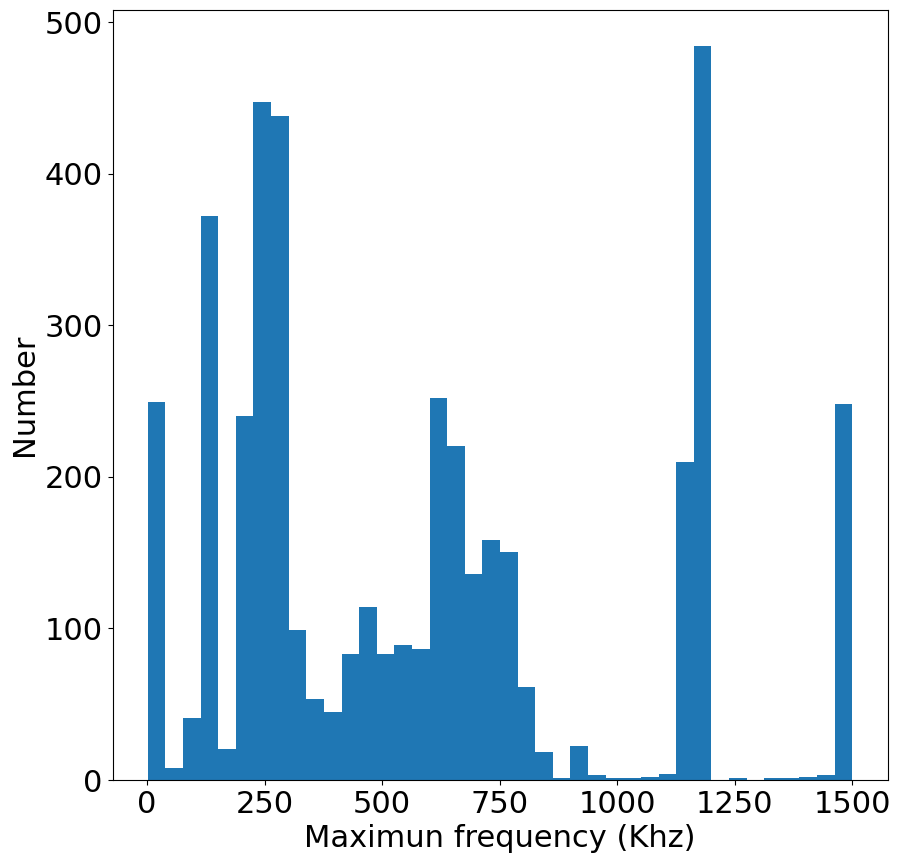

In [102]:
plt.figure(figsize=(10,10))
MaxFrqscp = MaxFreqs.copy()
MaxFrqscp[MaxFreqs>1500] = 1500
plt.hist(MaxFrqscp[Labels==1],bins=40)
plt.xlabel('Maximun frequency (Khz)')
plt.ylabel('Number')
plt.show()

In [103]:
MaxFreqs.shape,Labels.shape

((11189,), (11189,))

## OBSTransformer

In [104]:
Ro,xo,No, Ao = try_HZ(pred_list_OBS13[Labels!=2],MaxFreqs[Labels!=2],Labels[Labels!=2])

In [105]:
x = xo[1:]/2 + xo[:-1]/2

In [106]:
x

array([ 350.,  450.,  550.,  650.,  750.,  850.,  950., 1050., 1150.,
       1250., 1350.])

## IsAE

In [107]:
RIs,xis,Nis, Ais = try_HZ(pred_list_IsAE13[Labels!=2],MaxFreqs[Labels!=2],Labels[Labels!=2])

## CRED

In [108]:
Rcr,xcr,Ncr, Acr = try_HZ(pred_list_Cred13[Labels!=2],MaxFreqs[Labels!=2],Labels[Labels!=2])

## Figure

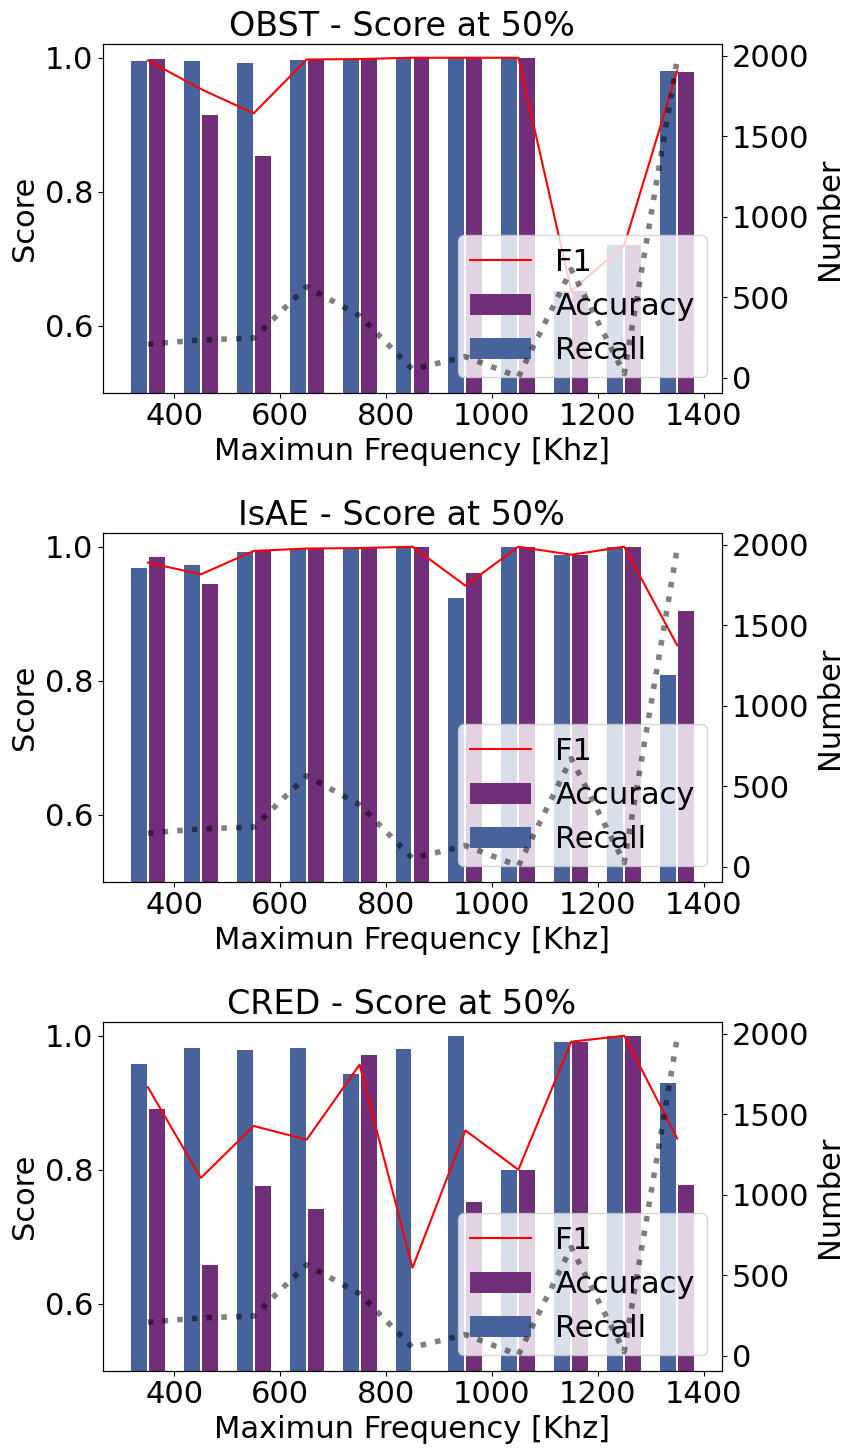

Cred Mean ACC and Recall  0.8043150634379453 0.9586435595957877
OBST Mean ACC and Recall  0.9193281462695502 0.9389030180681304
IsAE Mean ACC and Recall  0.9795614056126415 0.9678337355357417


In [109]:
plt.figure(figsize=(9,15))
plt.subplot(3,1,1)
n=1*2
offset=(1/n)
plt.bar(x+17 ,Ao,width=(x[1]-x[0])*0.6/2,label='Accuracy',color='#712F79')
plt.bar(x-17 ,Ro,width=(x[1]-x[0])*0.6/2,label='Recall',color='#48639C')
plt.plot(x,2*Ao*Ro/(Ro+Ao+1e-11),c='r',label='F1')
plt.xlabel('Maximun Frequency [Khz]')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.ylim([0.5,1.02])
plt.twinx()
plt.plot(x,No,color='k',ls = ':',lw=4,alpha=0.5)
plt.ylabel('Number')
plt.title('OBST - Score at 50%  ')

plt.subplot(3,1,2)
n=1*2
offset=(1/n)
plt.bar(x+17 ,Ais,width=(x[1]-x[0])*0.6/2,label='Accuracy',color='#712F79')
plt.bar(x-17 ,RIs,width=(x[1]-x[0])*0.6/2,label='Recall',color='#48639C')
plt.plot(x,2*Ais*RIs/(RIs+Ais+1e-11),c='r',label='F1')
plt.xlabel('Maximun Frequency [Khz]')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.ylim([0.5,1.02])
plt.twinx()
plt.plot(x,No,color='k',ls = ':',lw=4,alpha=0.5)
plt.ylabel('Number')
plt.title('IsAE - Score at 50%  ')

plt.subplot(3,1,3)
n=1*2
offset=(1/n)
plt.bar(x+17 ,Acr,width=(x[1]-x[0])*0.6/2,label='Accuracy',color='#712F79')
plt.bar(x-17 ,Rcr,width=(x[1]-x[0])*0.6/2,label='Recall',color='#48639C')
plt.plot(x,2*Acr*Rcr/(Rcr+Acr+1e-11),c='r',label='F1')
plt.xlabel('Maximun Frequency [Khz]')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.ylim([0.5,1.02])
plt.twinx()
plt.plot(x,Ncr,color='k',ls = ':',lw=4,alpha=0.5)
plt.ylabel('Number')
plt.title('CRED - Score at 50%  ')
plt.tight_layout()
plt.savefig('Figure/Freq_Compare.svg', format='SVG', dpi=200, bbox_inches='tight')
plt.show()

print('Cred Mean ACC and Recall ',np.nanmean(Acr),np.nanmean(Rcr))
print('OBST Mean ACC and Recall ',np.nanmean(Ao),np.nanmean(Ro))
print('IsAE Mean ACC and Recall ',np.nanmean(Ais),np.nanmean(RIs))

# Merge figure

In [460]:
BestP1,BestT2

({'Cred': np.float64(0.8618386077574995),
  'EQT': np.float64(0.7371735240719826),
  'GPD': np.float64(0.9353830383763277),
  'PhaseNet': np.float64(0.6666666666622222),
  'OBS': np.float64(0.9784320980357724),
  'IsAE': np.float64(0.9942162312803303),
  'IsAEMIN': np.float64(0.9942162312803303)},
 {'Cred': np.float64(0.55),
  'EQT': np.float64(0.01),
  'GPD': np.float64(0.39),
  'PhaseNet': np.float64(0.0),
  'OBS': np.float64(0.43),
  'IsAE': np.float64(0.01),
  'IsAEMIN': np.float64(0.0)})

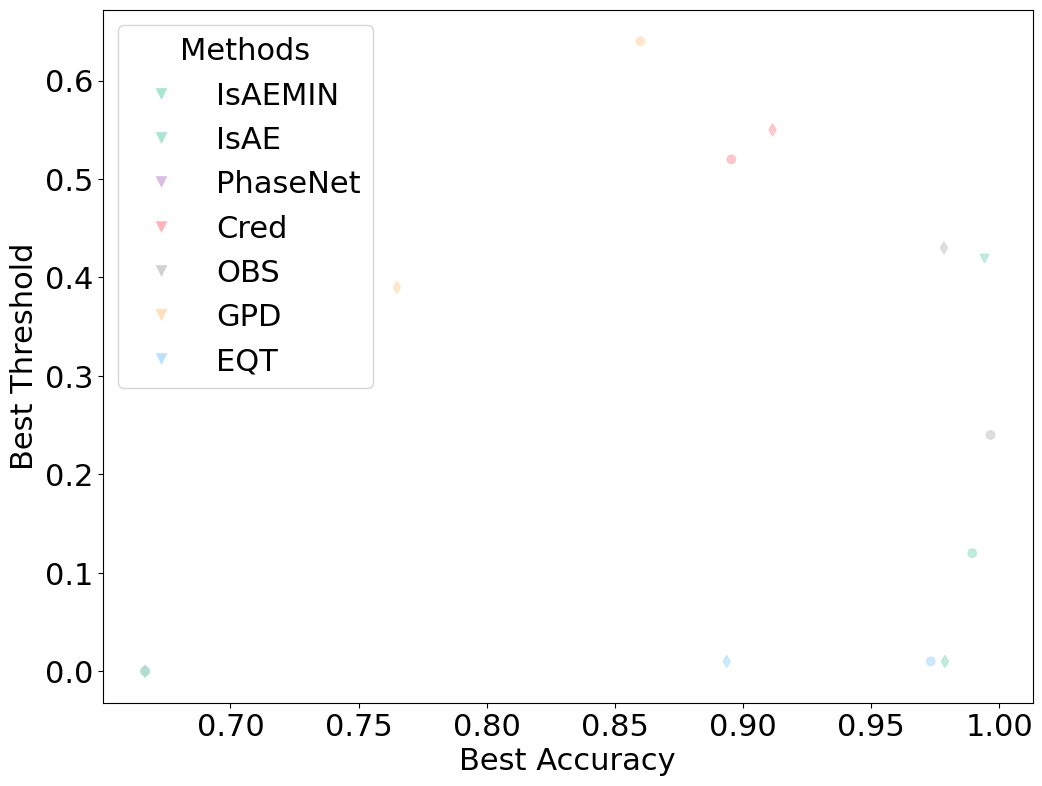

In [416]:
mklist = ['v','o','x','+','8']
colordic = {
    'IsAEMIN': '#A8E6CF',    # Pastel green
    'IsAE': '#A8E6CF',    # Pastel green
    'PhaseNet': '#D7BDE2', # Pastel purple
    'Cred': '#FFB3BA',    # Pastel red
    'OBS': '#D2D2D2',     # Pastel gray
    'GPD': '#FFDFBA',    # Pastel orange
    'EQT': '#BAE1FF'     # Pastel blue
}

plt.figure(figsize=(12, 9))
dkey = list(BestP1.keys())
bestP_k = [BestP1[x] for x in list(BestP1.keys())]
bestT_k = [BestT1[x] for x in list(BestP1.keys())]
Colortemp = [colordic[x] for x in list(BestP1.keys())]

# Scatter plot
scatter = plt.scatter(bestP_k, bestT_k, color=Colortemp, marker='v',alpha=0.7)


dkey = list(BestP2.keys())
bestP_k = [BestP2[x] for x in list(BestP2.keys())]
bestT_k = [BestT2[x] for x in list(BestP2.keys())]
Colortemp = [colordic[x] for x in list(BestP2.keys())]

# Scatter plot
scatter = plt.scatter(bestP_k, bestT_k, color=Colortemp, marker='d',alpha=0.7)


dkey = list(BestP2.keys())
bestP_k = [BestP3[x] for x in list(BestP2.keys())]
bestT_k = [BestT3[x] for x in list(BestP2.keys())]
Colortemp = [colordic[x] for x in list(BestP2.keys())]

# Scatter plot
scatter = plt.scatter(bestP_k, bestT_k, color=Colortemp, marker='o',alpha=0.7)


# Create legend handles
legend_labels = list(colordic.keys())
legend_colors = list(colordic.values())
legend_handles = [plt.Line2D([0], [0], marker='v', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in zip(legend_labels, legend_colors)]

# Add legend
plt.legend(handles=legend_handles, title='Methods')

plt.xlabel('Best Accuracy')
plt.ylabel('Best Threshold')
plt.show()

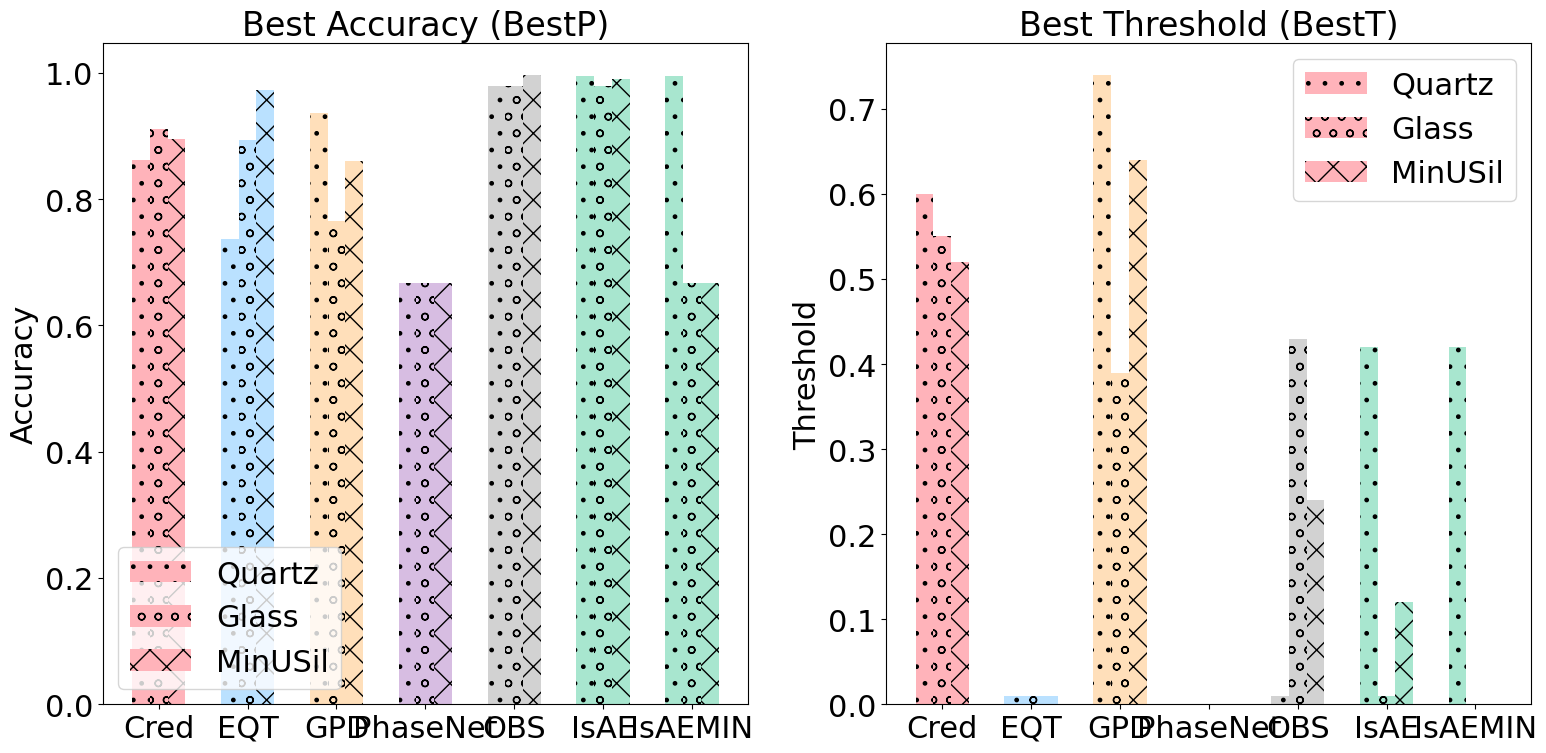

In [461]:
# Hatch patterns for each dictionary
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

# Prepare data for plotting
methods = ['Cred','EQT','GPD','PhaseNet','OBS','IsAE']
bar_width = 0.2

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar plot for BestP values
x_indexes = np.arange(len(methods))
ax1.bar(x_indexes - bar_width, [BestP1[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Quartz', hatch=hatches[-2])
ax1.bar(x_indexes, [BestP2[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Glass', hatch=hatches[6])
ax1.bar(x_indexes + bar_width, [BestP3[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='MinUSil', hatch=hatches[5])
ax1.set_title('Best Accuracy (BestP)')
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(methods)
ax1.set_ylabel('Accuracy')
ax1.legend(loc=3)

# Bar plot for BestT values
ax2.bar(x_indexes - bar_width, [BestT1[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Quartz', hatch=hatches[-2])
ax2.bar(x_indexes, [BestT2[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Glass', hatch=hatches[6])
ax2.bar(x_indexes + bar_width, [BestT3[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='MinUSil', hatch=hatches[5])
ax2.set_title('Best Threshold (BestT)')
ax2.set_xticks(x_indexes)
ax2.set_xticklabels(methods)
ax2.set_ylabel('Threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('Figure/bar_plots_with_hatch.svg', format='SVG', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Hatch patterns for each dictionary
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

# Prepare data for plotting
methods = ['IsAE','IsAEMIN']
bar_width = 0.2

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar plot for BestP values
x_indexes = np.arange(len(methods))
ax1.bar(x_indexes - bar_width, [BestP1[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Quartz', hatch=hatches[-2])
ax1.bar(x_indexes, [BestP2[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Glass', hatch=hatches[6])
ax1.bar(x_indexes + bar_width, [BestP3[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='MinUSil', hatch=hatches[5])
ax1.set_title('Best Accuracy (BestP)')
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(methods)
ax1.set_ylabel('Accuracy')
ax1.legend(loc=3)

# Bar plot for BestT values
ax2.bar(x_indexes - bar_width, [BestT1[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Quartz', hatch=hatches[-2])
ax2.bar(x_indexes, [BestT2[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='Glass', hatch=hatches[6])
ax2.bar(x_indexes + bar_width, [BestT3[m] for m in methods], width=bar_width,
        color=[colordic[m] for m in methods], label='MinUSil', hatch=hatches[5])
ax2.set_title('Best Threshold (BestT)')
ax2.set_xticks(x_indexes)
ax2.set_xticklabels(methods)
ax2.set_ylabel('Threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('Figure/bar_plots_IsAE_with_hatch.svg', format='SVG', dpi=200, bbox_inches='tight')
plt.show()

In [162]:
bestP_k,bestT_k,Colortemp

([np.float64(0.8618386077574995),
  np.float64(0.8618386077574995),
  np.float64(0.9353830383763277)],
 [np.float64(0.6), np.float64(0.6), np.float64(0.74)],
 ['r', 'b', 'orange'])

In [129]:
import os
import re
import cairosvg
from PIL import Image, ImageDraw, ImageFont

def combine_figures_vertically(folder_path):
    # Get all SVG files in the folder
    files = [f for f in os.listdir(folder_path) if f.endswith('.svg')]

    # Group files by datatype and dataset
    groups = {}
    for file in files:
        try:
            model_name, datatype, dataset = re.match(r"([^_]+)_([^_]+)_([^_]+)\.svg", file).groups()
            key = (datatype, dataset)
            if key not in groups:
                groups[key] = []
            groups[key].append((model_name, file))
        except AttributeError:
            print(f"Skipping file {file}: filename does not match expected pattern.")
            continue

    # Combine figures for each group
    for (datatype, dataset), models_files in groups.items():
        # Convert SVG to PNG and open images
        images = []
        png_files = []
        for model_name, svg_file in models_files:
            svg_path = os.path.join(folder_path, svg_file)
            png_path = svg_path.replace('.svg', '.png')
            cairosvg.svg2png(url=svg_path, write_to=png_path)
            images.append(Image.open(png_path))
            png_files.append(png_path)

        # Combine images vertically
        widths, heights = zip(*(img.size for img in images))
        total_height = sum(heights)
        max_width = max(widths)

        combined_img = Image.new('RGB', (max_width, total_height))

        y_offset = 0
        for (model_name, _), img in zip(models_files, images):
            # Add model_name text to the top-left corner of each sub-figure
            draw = ImageDraw.Draw(img)
            try:
                font = ImageFont.truetype("FreeMono.ttf", 30)
            except IOError:
                font = ImageFont.load_default()
            draw.text((0, 0), model_name, fill="black", font=font)
            # Paste the image into the combined image
            combined_img.paste(img, (0, y_offset))
            y_offset += img.size[1]

        # Save the combined image
        output_filename = f"combined_{datatype}_{dataset}.png"
        combined_img.save(os.path.join(folder_path, output_filename))

        # Clean up temporary PNG files
        for png_file in png_files:
            os.remove(png_file)

# Example usage
folder_path = "Figure"  # Replace with your folder path
combine_figures_vertically(folder_path)


In [116]:
font = ImageFont.load_default()

# Do Save

In [350]:
def save_all_dicts_to_pickle(filename='all_dicts.pkl'):
    """
    Save all dictionaries in the global environment to a pickle file.

    Args:
        filename (str): Name of the pickle file.
    """
    global_vars = globals()
    dicts_to_save = {name: obj for name, obj in global_vars.items()
                     if isinstance(obj, dict) and not name.startswith('__') and ('chrono' in name or 'Best' in name)}
    with open(filename, 'wb') as f:
        pickle.dump(dicts_to_save, f)
    print([ k for k in  dicts_to_save.keys()] )
    print(f"Saved {len(dicts_to_save)} dictionaries to {filename}")

def load_all_dicts_from_pickle(filename='all_dicts.pkl'):
    """
    Load all dictionaries from a pickle file back into the global environment.

    Args:
        filename (str): Name of the pickle file.
    """
    with open(filename, 'rb') as f:
        loaded_dicts = pickle.load(f)
    for name, obj in loaded_dicts.items():
        globals()[name] = obj
    print(f"Loaded {len(loaded_dicts)} dictionaries from {filename}")

# Example usage:
# Save all dictionaries
save_all_dicts_to_pickle()





['BestP2', 'BestT2', 'BestP3', 'BestT3', 'chrono2', 'chrono3', 'BestP1', 'BestT1', 'chrono']
Saved 9 dictionaries to all_dicts.pkl


In [ ]:
# Load

In [419]:

# Later, load them back
load_all_dicts_from_pickle()


Loaded 9 dictionaries from all_dicts.pkl


# Showcase on Continuous Data

In [ ]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()encodelast

In [137]:
from scipy import signal
from tqdm import tqdm
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x-x.mean()) / x.std() if x.std() > 0 else x-x.mean()),
])


def predict(model, data):
    model.eval()  # Set model to evaluation mode

    (image, label) = data
    # Get the first sample
    image = image.unsqueeze(0).to(device).float()  # Add batch dimension
    if label != '?':
        true_label = label.unsqueeze(0).to(device).float()
        label=true_label.cpu().numpy()

    with torch.no_grad():  # No gradient calculation
        logits = model(image)  # Raw model output
        #probability = torch.sigmoid(logits)  # Convert to probability
        #prediction = (probability >= 0.5).float()  # Convert to binary (0 or 1)

    return label, logits.cpu().numpy()
    
def real_test(x_raw):
    fs = 10e6
    tt = np.arange(0,len(x_raw))/fs
    windows = 0.00080 # in seconde
    n_w = int(windows * fs) # nunber of point per windows windows

    overlap_x = n_w // 2 # overlap over 50% of the windows
    #print(n_w)
    overlap_x = int(n_w*0.8) #1924 # overlap 1200 over 1500 one
    step_x = n_w - overlap_x

    slices_x = [x_raw[i:i + n_w]  for i in range(0, len(x_raw) - n_w, step_x)]
    slices_t = [tt[i:i + n_w]  for i in range(0, len(tt) - n_w, step_x)]

    res = []
    for x_filt in tqdm(slices_x) :
        n_fft = int(100*2.52)
        window = np.hanning(n_fft)
        overlap = int(n_fft * 0.8)
        step = n_fft - overlap
        slices = [x_filt[i:i + n_fft] * window for i in range(0, len(x_filt) - n_fft, step)]
        stft = np.fft.fft(slices, axis=1)
        ifft_result = np.fft.ifft(stft, axis=1)
        Im = np.abs(ifft_result.T)
        image = transform(Im)
        
        index_to_remove = 154
        new_tensor = image[..., :index_to_remove]
        #print(np.shape(image))
        pad_size = 156-np.shape(image)[2]
        #print(pad_size,np.shape(new_tensor))
        padding = (0, pad_size)  # Pad only the last dimension

        # Apply padding
        padded_tensor = F.pad(image, padding, "constant", 0)
        
        true_label,  logit = predict(model, (padded_tensor,'?'))
        #print(np.around(logit,3), np.around(logit[0][1],3))
        logit = logit[0][0]
        res.append(np.around(logit,3))
    return res,slices_x,slices_t

In [170]:

x_raw = np.load('/home/jupyter-septier/PhdFolder_Liverpool/Rock_data/Gouge_qwartz110_150725/chm_2025-07-15 16:42:05.155421.npy')

fs = 1e7 # targeted sampling rate
tt = np.arange(0,len(x_raw))/fs
windows = 0.00080 # in seconde
n_w = int(windows * fs) # nunber of point per windows windows

overlap = int(n_w*0.8)#1400#n_w // 4 # overlap over 50% of the windows
print(overlap)
step = n_w - overlap

slices = [x_raw[i:i + n_w]  for i in range(0, len(x_raw) - n_w, step)]


7999


In [171]:
res,slices_x,slices_t=real_test(x_raw)

100%|██████████| 10481/10481 [00:34<00:00, 304.77it/s]


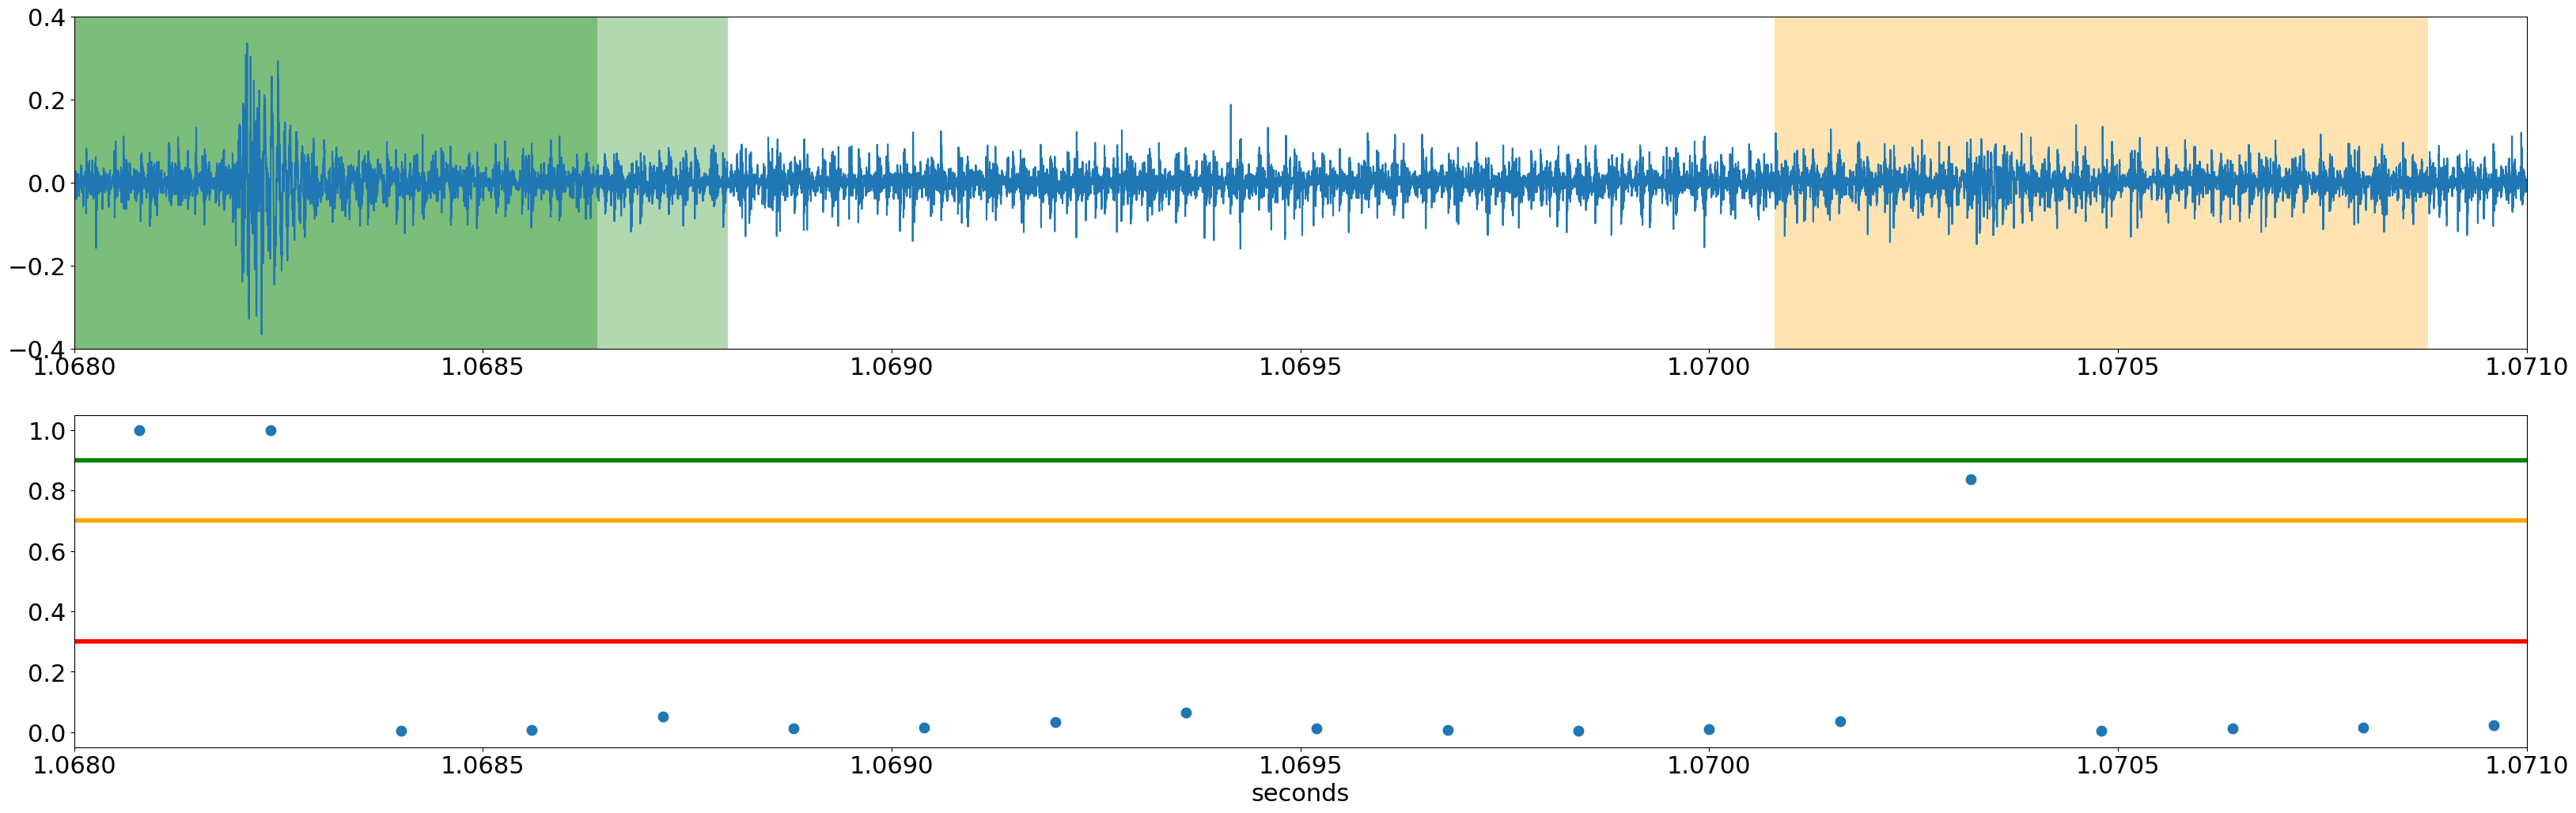

In [172]:
plt.figure(figsize=(40,12))
ax1 =plt.subplot(2,1,1)
plt.plot(tt,x_raw)
res_moy = [ (res[i-1] + res[(i+1,0)[i+1==len(res)]] + 2*res[i])/4 for i in range(len(res))]
for r in range(len(res)):
    if res[r] > 0.9 :
        plt.axvspan( np.min(slices_t[r]),  np.max(slices_t[r]), facecolor='green', alpha=0.3)
    elif res[r] > 0.7:
        plt.axvspan( np.min(slices_t[r]),  np.max(slices_t[r]), facecolor='orange', alpha=0.3)
    elif res[r] > 0.3 :
        plt.axvspan( np.min(slices_t[r]),  np.max(slices_t[r]), facecolor='red', alpha=0.3)

plt.ylim([-0.4,0.4])
plt.subplot(2,1,2, sharex=ax1)
t_r_plot = [  np.min(slices_t[r-1])/2 +   np.max(slices_t[r-1])/2 for r in range(len(res)) ]
#r_plot = [ float(res[r][0][1]) for r in range(len(res))]
#r_moy_plot = [ float(res_moy[r][0][0]) for r in range(len(res))]
plt.axhline(0.9,0,1,lw=4,color='green')
plt.axhline(0.7,0,1,lw=4,color='orange')
plt.axhline(0.3,0,1,lw=4,color='red')
#plt.scatter(t_r_plot,r_plot,lw=4)
plt.scatter(t_r_plot,res,lw=4)
#plt.scatter(t_r_plot,r_moy_plot,lw=4)
plt.xlim([1.068,1.071])
plt.xlabel("seconds")
plt.show()

## Denoising 